# Barclays Credit Intelligence Pipeline (Single-Flow Notebook)

This notebook has one official path and one official model for deployment.

Official winner to carry forward: `winner_v4_user_specific`.

If you are reviewing quickly, use this order only:

1. Setup + data preparation sections.
2. Winner v4 training/evaluation section.
3. Final Governance Lock section.
4. Winner-Only Inference Pipeline section.
5. Advanced Controls section (calibration audit, denoise freeze, shadow export).

Everything else is historical experimentation context and can be treated as supporting evidence, not the active deployment path.

## Read This Before Running

Execution intent for this notebook is now standardized:

1. Build and validate the winner candidate.
2. Lock governance with mandatory segment recall floors.
3. Run winner-only scoring with guardrails.
4. Export artifacts for backend integration and shadow monitoring.

Decision policy: if any section output conflicts with the lock file, trust the lock file and winner-only inference outputs.

In [61]:
# Optional for fresh kernel environments
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm catboost shap imbalanced-learn optuna

from pathlib import Path
import os
import sys
import json
import random
import time
import ctypes
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# macOS OpenMP fix for XGBoost when Homebrew libomp is unavailable
omp_candidates = glob.glob(str(Path(sys.prefix) / 'lib' / 'python*' / 'site-packages' / 'sklearn' / '.dylibs' / 'libomp.dylib'))
if omp_candidates:
    omp_dir = str(Path(omp_candidates[0]).parent)
    os.environ['DYLD_LIBRARY_PATH'] = omp_dir + (':' + os.environ['DYLD_LIBRARY_PATH'] if os.environ.get('DYLD_LIBRARY_PATH') else '')
    try:
        ctypes.CDLL(omp_candidates[0])
    except Exception as e:
        print('OpenMP preload warning:', e)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    XGBClassifier = None

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    shap = None

# Optional advanced libraries with graceful fallback
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False
    CatBoostClassifier = None

try:
    import optuna
    HAS_OPTUNA = True
except Exception:
    HAS_OPTUNA = False
    optuna = None

# Robust project root discovery for notebook kernels launched outside workspace
search_starts = [
    Path.cwd().resolve(),
    Path('/Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform').resolve(),
    Path('/Users/shlokpalrecha/Desktop/Barclays').resolve(),
]
PROJECT_ROOT = None
for start in search_starts:
    p = start
    while True:
        if (p / 'ml_pipeline').exists() and (p / 'README.md').exists():
            PROJECT_ROOT = p
            break
        if p == p.parent:
            break
        p = p.parent
    if PROJECT_ROOT is not None:
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root containing ml_pipeline')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml_pipeline.config import PipelineConfig, GMSC_FEATURES, HOME_CREDIT_FEATURES
from ml_pipeline.data_sources import (
    load_gmsc_train, load_home_credit_train, load_mytransaction,
    load_installments, load_previous_applications
)
from ml_pipeline.feature_engineering import (
    engineer_gmsc_features, engineer_home_credit_features,
    aggregate_installments, aggregate_previous_applications, extract_transaction_features
)

print('Project root:', PROJECT_ROOT)
print('Python:', sys.version.split()[0])
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('XGBoost available:', HAS_XGBOOST)
print('LightGBM available:', HAS_LGBM)
print('CatBoost available:', HAS_CATBOOST)
print('SHAP available:', HAS_SHAP)
print('Optuna available:', HAS_OPTUNA)

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Project root: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform
Python: 3.9.6
Pandas: 2.2.1
NumPy: 1.26.4
XGBoost available: True
LightGBM available: False
CatBoost available: True
SHAP available: True
Optuna available: True


## 1) Setup and Reproducibility



In this section I import libraries, set seeds, and define configuration values so results are reproducible across reruns.


In [62]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Choose dataset: 'gmsc' or 'home_credit'
DATASET_CHOICE = 'gmsc'

# QUICK_MODE=True for fast iteration, False for full-scale training
QUICK_MODE = True
ROW_LIMITS = {
    'gmsc': 100000,
    'home_credit': 200000,
}

TARGET_MAP = {'gmsc': 'SeriousDlqin2yrs', 'home_credit': 'TARGET'}

# Protected attributes to NEVER use for model training
PROTECTED_ATTRS = ['CODE_GENDER', 'gender', 'religion', 'ethnicity', 'caste']

config = PipelineConfig()
DATA_ROOT = config.raw_data_root
OUT_DIR = config.output_dir
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 200)

print('Dataset choice:', DATASET_CHOICE)
print('Quick mode:', QUICK_MODE)
print('Data root:', DATA_ROOT)
print('Output dir:', OUT_DIR)

Dataset choice: gmsc
Quick mode: True
Data root: /Users/shlokpalrecha/Desktop/Barclays/datasets/raw
Output dir: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models


In [63]:
all_dataset_paths = {
    'gmsc_train': DATA_ROOT / 'give-me-some-credit' / 'cs-training.csv',
    'gmsc_test': DATA_ROOT / 'give-me-some-credit' / 'cs-test.csv',
    'gmsc_submission': DATA_ROOT / 'give-me-some-credit' / 'sampleEntry.csv',
    'mytransaction': DATA_ROOT / 'my-transaction' / 'MyTransaction.csv',
    'home_train': DATA_ROOT / 'home-credit' / 'application_train.csv',
    'home_test': DATA_ROOT / 'home-credit' / 'application_test.csv',
    'home_desc': DATA_ROOT / 'home-credit' / 'HomeCredit_columns_description.csv',
    'home_installments': DATA_ROOT / 'home-credit' / 'installments_payments.csv',
    'home_previous': DATA_ROOT / 'home-credit' / 'previous_application.csv',
    'home_bureau': DATA_ROOT / 'home-credit' / 'bureau.csv',
    'home_bureau_balance': DATA_ROOT / 'home-credit' / 'bureau_balance.csv',
    'home_credit_card': DATA_ROOT / 'home-credit' / 'credit_card_balance.csv',
    'home_pos_cash': DATA_ROOT / 'home-credit' / 'POS_CASH_balance.csv',
    'paysim_fraud_log': DATA_ROOT / 'paysim-fraud' / 'PS_20174392719_1491204439457_log.csv',
    'lending_club_loan': DATA_ROOT / 'lending-club' / 'loan.csv',
    'lending_club_dict': DATA_ROOT / 'lending-club' / 'LCDataDictionary.xlsx',
}

coverage_rows = []
for name, path in all_dataset_paths.items():
    exists = path.exists()
    size_mb = round(path.stat().st_size / (1024 * 1024), 2) if exists else None
    coverage_rows.append({'dataset': name, 'exists': exists, 'size_mb': size_mb, 'path': str(path)})

coverage_df = pd.DataFrame(coverage_rows).sort_values('dataset')
display(coverage_df)

missing_any = coverage_df.loc[~coverage_df['exists'], 'dataset'].tolist()
assert not missing_any, f'Missing datasets: {missing_any}'
print('All discussed datasets are present in canonical layout.')

,dataset,exists,size_mb,path
2,gmsc_submission,True,1.82,/Users/shlokpalrecha/Desktop/Barclays/datasets...
1,gmsc_test,True,4.75,/Users/shlokpalrecha/Desktop/Barclays/datasets...
0,gmsc_train,True,7.21,/Users/shlokpalrecha/Desktop/Barclays/datasets...
9,home_bureau,True,162.14,/Users/shlokpalrecha/Desktop/Barclays/datasets...
10,home_bureau_balance,True,358.19,/Users/shlokpalrecha/Desktop/Barclays/datasets...
11,home_credit_card,True,404.91,/Users/shlokpalrecha/Desktop/Barclays/datasets...
6,home_desc,True,0.04,/Users/shlokpalrecha/Desktop/Barclays/datasets...
7,home_installments,True,689.62,/Users/shlokpalrecha/Desktop/Barclays/datasets...
12,home_pos_cash,True,374.51,/Users/shlokpalrecha/Desktop/Barclays/datasets...
8,home_previous,True,386.21,/Users/shlokpalrecha/Desktop/Barclays/datasets...


All discussed datasets are present in canonical layout.


## 2) Data Ingestion (Mandatory)

Purpose: load all discussed datasets and verify availability before modeling.

What you should see in this stage:

1. Dataset coverage table with `exists=True` for required files.
2. Loaded base training frame (`df_raw`) with shape, target column, and sample rows.
3. Profile snapshots for MyTransaction, PaySim, and Lending Club supporting files.

## 3) Initial Data Profiling



Before feature engineering, I run quick profiling checks to understand class balance, cardinality, missingness, and obvious quality issues.


In [64]:
if DATASET_CHOICE == 'gmsc':
    nrows = ROW_LIMITS['gmsc'] if QUICK_MODE else None
    df_raw = load_gmsc_train(config, nrows=nrows)
    target_col = TARGET_MAP['gmsc']
elif DATASET_CHOICE == 'home_credit':
    nrows = ROW_LIMITS['home_credit'] if QUICK_MODE else None
    df_raw = load_home_credit_train(config, nrows=nrows)
    target_col = TARGET_MAP['home_credit']
else:
    raise ValueError("DATASET_CHOICE must be 'gmsc' or 'home_credit'")

print('Loaded dataset:', DATASET_CHOICE)
print('Shape:', df_raw.shape)
print('Target column:', target_col)
print('Columns:', len(df_raw.columns))
display(df_raw.head(3))

Loaded dataset: gmsc
Shape: (99999, 13)
Target column: SeriousDlqin2yrs
Columns: 13


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_group,MonthlyIncome_was_imputed
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2,40-50,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1,30-40,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0,30-40,0


In [65]:
# MyTransaction profile
tx_head = pd.read_csv(all_dataset_paths['mytransaction'], encoding='utf-8-sig', nrows=5)
tx_count = sum(1 for _ in open(all_dataset_paths['mytransaction'], 'r', encoding='utf-8-sig')) - 1

# PaySim fraud profile (sampled read)
ps_sample = pd.read_csv(all_dataset_paths['paysim_fraud_log'], nrows=200000)
fraud_rate_est = float(ps_sample['isFraud'].mean())
flagged_rate_est = float(ps_sample['isFlaggedFraud'].mean())

# Lending Club profile (header + small sample)
lc_sample = pd.read_csv(all_dataset_paths['lending_club_loan'], nrows=50000, low_memory=False)
lc_cols = len(lc_sample.columns)
lc_rows_sample = len(lc_sample)

profile = pd.DataFrame([
    {'dataset': 'MyTransaction', 'sample_rows': len(tx_head), 'total_rows_estimate': tx_count, 'columns': len(tx_head.columns)},
    {'dataset': 'PaySim_fraud_log', 'sample_rows': len(ps_sample), 'total_rows_estimate': None, 'columns': len(ps_sample.columns), 'fraud_rate_sample': fraud_rate_est, 'flagged_rate_sample': flagged_rate_est},
    {'dataset': 'LendingClub_loan', 'sample_rows': lc_rows_sample, 'total_rows_estimate': None, 'columns': lc_cols},
])
display(profile)
display(tx_head)

,dataset,sample_rows,total_rows_estimate,columns,fraud_rate_sample,flagged_rate_sample
0,MyTransaction,5,1470.0,7,NaN,NaN
1,PaySim_fraud_log,200000,NaN,11,0.000735,0.0
2,LendingClub_loan,50000,NaN,145,NaN,NaN


,Date,Category,RefNo,Date.1,Withdrawal,Deposit,Balance
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/1/2023,Rent,3.000000e+11,1/1/2023,3950.0,0.0,1837.23
2,3/1/2023,Misc,3.000000e+11,3/1/2023,105.0,0.0,1732.23
3,3/1/2023,Misc,3.370000e+11,3/1/2023,0.0,55.0,1787.23
4,3/1/2023,Food,3.000000e+11,3/1/2023,56.0,0.0,1731.23


## 4) Leakage and Data Hygiene Checks (Mandatory)

Purpose: prevent shortcut learning and keep training signals trustworthy.

What you should see in this stage:

1. Target integrity check (binary 0/1).
2. Duplicate-row count and missingness summary.
3. Data sanity assertions that fail fast on suspicious input quality.

## 5) Missing Value Strategy



This block defines how missing values are handled consistently across train/validation/test, so there is no information leakage from preprocessing.


In [66]:
assert target_col in df_raw.columns, f'Missing target column: {target_col}'
assert set(df_raw[target_col].dropna().unique()).issubset({0, 1}), 'Target must be binary 0/1'

missing_top = df_raw.isna().mean().sort_values(ascending=False).head(20)
dupes = int(df_raw.duplicated().sum())

print('Duplicate rows:', dupes)
print('Target distribution:')
display(df_raw[target_col].value_counts(normalize=True).rename('ratio').to_frame())
print('Top missing columns:')
display(missing_top.to_frame('missing_ratio'))

if 'age' in df_raw.columns:
    assert (df_raw['age'] >= 18).mean() > 0.99, 'Unexpected high count of invalid ages'

Duplicate rows: 416
Target distribution:


,ratio
SeriousDlqin2yrs,
0,0.933339
1,0.066661


Top missing columns:


,missing_ratio
SeriousDlqin2yrs,0.0
RevolvingUtilizationOfUnsecuredLines,0.0
age,0.0
NumberOfTime30-59DaysPastDueNotWorse,0.0
DebtRatio,0.0
MonthlyIncome,0.0
NumberOfOpenCreditLinesAndLoans,0.0
NumberOfTimes90DaysLate,0.0
NumberRealEstateLoansOrLines,0.0
NumberOfTime60-89DaysPastDueNotWorse,0.0


## 6) Target and Risk Signal Exploration



I inspect target behavior and core risk drivers to validate that the learning problem is coherent before model fitting.


In [67]:
if DATASET_CHOICE == 'gmsc':
    df_fe = engineer_gmsc_features(df_raw.copy())
    candidate_features = [f for f in GMSC_FEATURES if f in df_fe.columns]
else:
    df_fe = engineer_home_credit_features(df_raw.copy())
    inst = load_installments(config)
    prev = load_previous_applications(config)
    if inst is not None:
        df_fe = df_fe.merge(aggregate_installments(inst), on='SK_ID_CURR', how='left')
    if prev is not None:
        df_fe = df_fe.merge(aggregate_previous_applications(prev), on='SK_ID_CURR', how='left')
    candidate_features = [f for f in HOME_CREDIT_FEATURES if f in df_fe.columns]

# Remove protected attributes for fairness-safe training
train_features = [
    c for c in candidate_features
    if c not in PROTECTED_ATTRS and c.upper() not in {'CODE_GENDER', 'RELIGION', 'ETHNICITY', 'CASTE'}
]

X = df_fe[train_features].fillna(0)
y = df_fe[target_col].astype(int)

print('Transformed shape:', df_fe.shape)
print('Candidate features:', len(candidate_features))
print('Training features after exclusion:', len(train_features))
print('Any protected feature left:', any(c in PROTECTED_ATTRS for c in train_features))
display(pd.DataFrame({'feature': train_features}).head(20))

Transformed shape: (99999, 26)
Candidate features: 24
Training features after exclusion: 24
Any protected feature left: False


,feature
0,RevolvingUtilizationOfUnsecuredLines
1,age
2,NumberOfTime30-59DaysPastDueNotWorse
3,DebtRatio
4,MonthlyIncome
5,NumberOfOpenCreditLinesAndLoans
6,NumberOfTimes90DaysLate
7,NumberRealEstateLoansOrLines
8,NumberOfTime60-89DaysPastDueNotWorse
9,NumberOfDependents


In [68]:
tx_full = load_mytransaction(config)
tx_alt_features = extract_transaction_features(tx_full)
tx_alt_df = pd.DataFrame([tx_alt_features])
display(tx_alt_df.T.rename(columns={0: 'value'}))

tx_alt_out = OUT_DIR / f'transaction_alt_features_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(tx_alt_out, 'w', encoding='utf-8') as f:
    json.dump(tx_alt_features, f, indent=2)
print('Saved alternative data features:', tx_alt_out)

,value
income_stability,0.000000
salary_regularity,0.000000
cash_flow_volatility,0.848518
balance_stress_indicator,0.029877
savings_buffer_ratio,0.093806
spending_pattern_ratio,0.419571
transaction_consistency,0.413407
utility_payment_proxy,0.994872
avg_monthly_income,6504.757692
avg_monthly_expense,12387.274615


Saved alternative data features: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/transaction_alt_features_20260320_211237.json


## 7) Feature Engineering (Core Credit Features)



This section creates financially meaningful predictors such as affordability proxies, repayment burden indicators, and behavioral risk cues.


## 8) Segment-Aware Feature Layer



I add features specific to underserved user profiles (farmer, gig worker, homemaker, MSME, low-income salaried) to avoid a one-size-fits-all risk view.


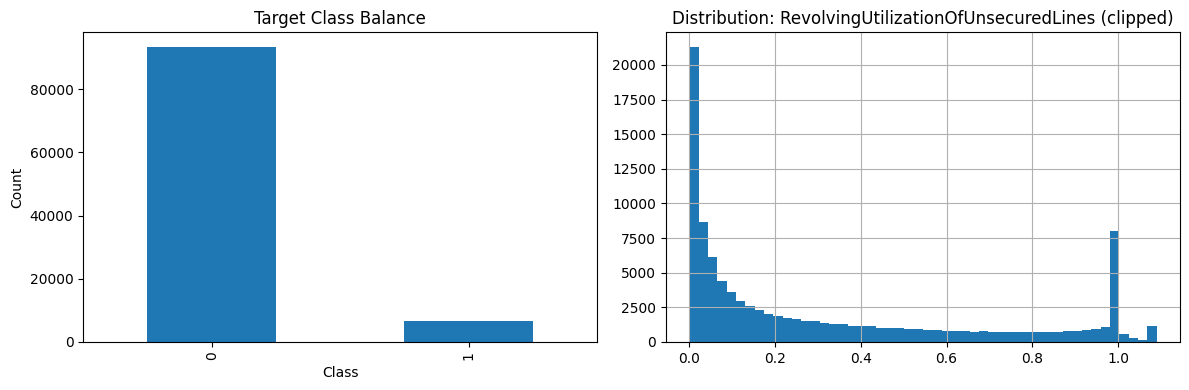

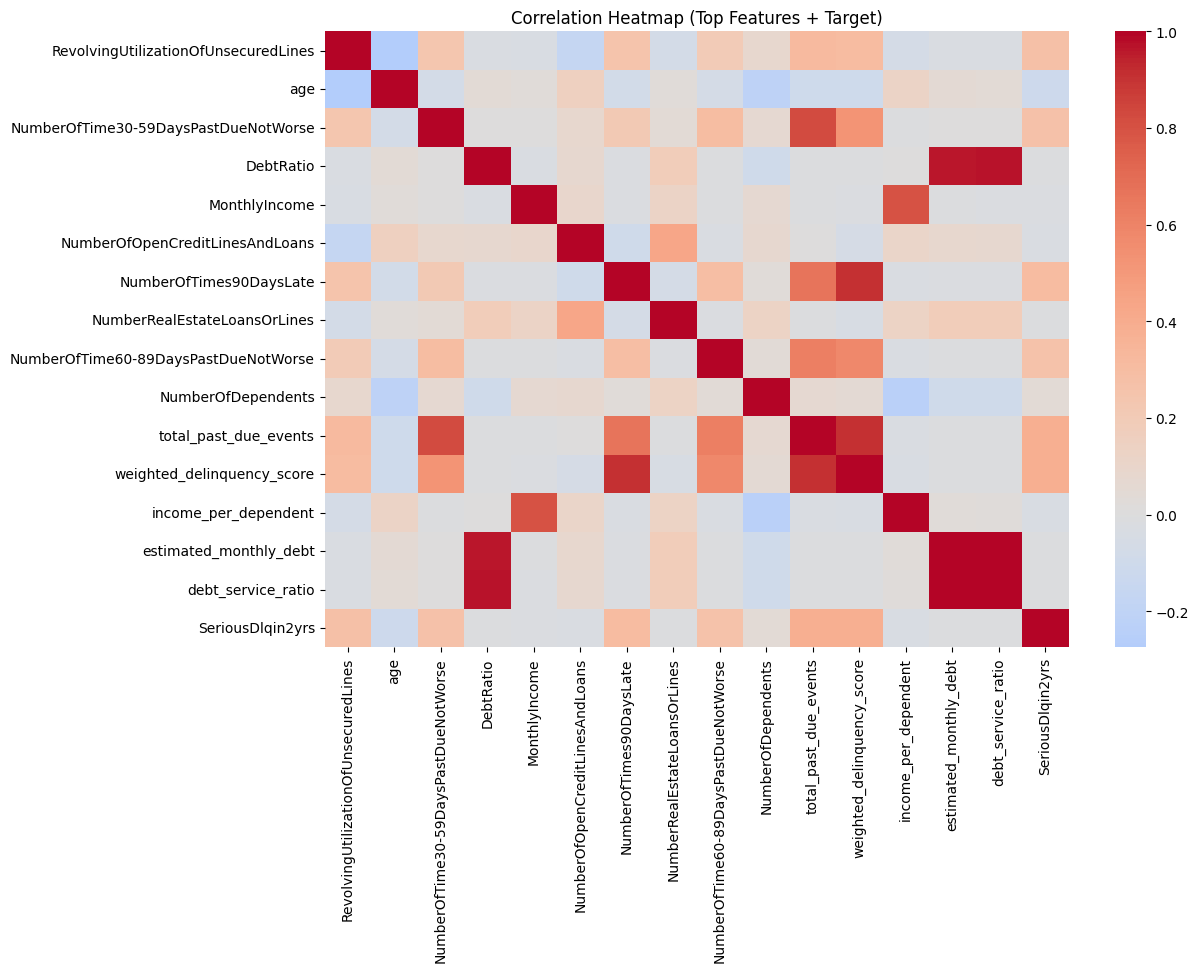

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Target Class Balance')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

plot_col = train_features[0] if train_features else None
if plot_col is not None:
    X[plot_col].clip(X[plot_col].quantile(0.01), X[plot_col].quantile(0.99)).hist(ax=axes[1], bins=50)
    axes[1].set_title(f'Distribution: {plot_col} (clipped)')
plt.tight_layout()
plt.show()

corr_cols = train_features[:15] + [target_col]
corr_df = pd.concat([X[corr_cols[:-1]], y.rename(target_col)], axis=1)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top Features + Target)')
plt.show()

## 9) Train/Validation/Test Construction



The split logic preserves realistic evaluation conditions and keeps preprocessing strictly within training boundaries.


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=SEED, stratify=y_train
)

train_meta = {'seed': SEED, 'dataset': DATASET_CHOICE, 'n_train': len(X_train), 'n_val': len(X_val), 'n_test': len(X_test)}
print(train_meta)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

t0 = time.time()
lr = LogisticRegression(class_weight='balanced', max_iter=1200, random_state=SEED)
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_time = time.time() - t0

xgb = None
xgb_time = np.nan
if HAS_XGBOOST:
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    t0 = time.time()
    xgb = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric='auc',
        random_state=SEED, n_jobs=-1
    )
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_time = time.time() - t0
else:
    print('Skipping XGBoost baseline because XGBoost is unavailable in this kernel.')

model_times = [
    {'model': 'logistic_regression', 'train_seconds': lr_time},
    {'model': 'random_forest', 'train_seconds': rf_time},
]
if xgb is not None:
    model_times.append({'model': 'xgboost', 'train_seconds': xgb_time})

model_times = pd.DataFrame(model_times)
display(model_times)

{'seed': 42, 'dataset': 'gmsc', 'n_train': 69999, 'n_val': 10000, 'n_test': 20000}


,model,train_seconds
0,logistic_regression,0.316027
1,random_forest,2.570229
2,xgboost,1.041536


## 10) Baseline Models and Candidate Comparison



I benchmark multiple model families first, then narrow down to robust candidates based on out-of-sample quality and business relevance.


,model,auc_roc,precision,recall,f1_score,accuracy,threshold
0,random_forest,0.860966,0.164250,0.858215,0.275729,0.6995,0.35
1,logistic_regression,0.855266,0.158920,0.869467,0.268722,0.6846,0.35
2,xgboost,0.854773,0.181247,0.822206,0.297019,0.7406,0.35


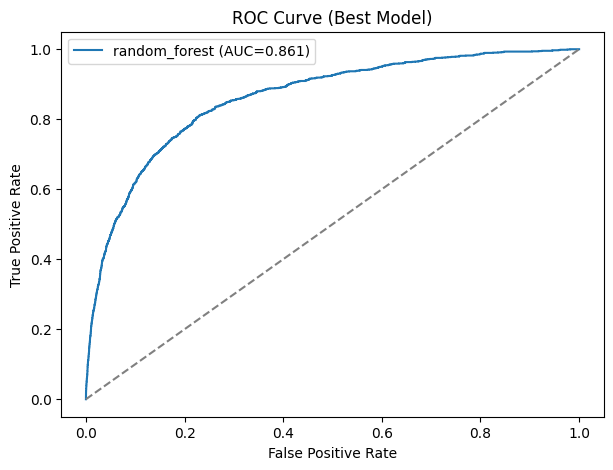

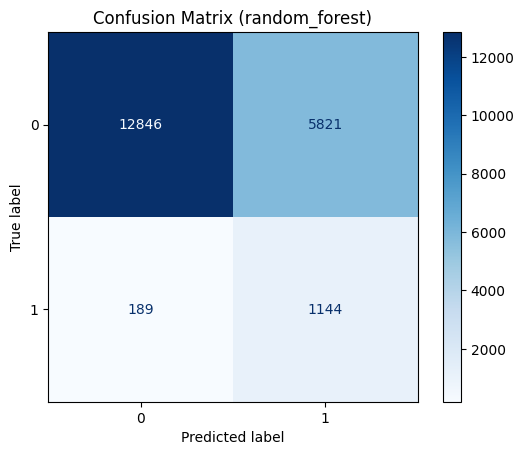

In [71]:
def evaluate_model(name, model, X_eval, y_eval, threshold=0.35, scaled=False):
    probs = model.predict_proba(X_eval)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        'model': name,
        'auc_roc': roc_auc_score(y_eval, probs),
        'precision': precision_score(y_eval, preds, zero_division=0),
        'recall': recall_score(y_eval, preds, zero_division=0),
        'f1_score': f1_score(y_eval, preds, zero_division=0),
        'accuracy': accuracy_score(y_eval, preds),
        'threshold': threshold,
        'probs': probs,
        'preds': preds,
    }

res_lr = evaluate_model('logistic_regression', lr, X_test_scaled, y_test, threshold=0.35)
res_rf = evaluate_model('random_forest', rf, X_test, y_test, threshold=0.35)
res_xgb = evaluate_model('xgboost', xgb, X_test, y_test, threshold=0.35)

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['probs', 'preds']} for r in [res_lr, res_rf, res_xgb]])
metrics_df = metrics_df.sort_values('auc_roc', ascending=False).reset_index(drop=True)
display(metrics_df)

best_name = metrics_df.iloc[0]['model']
best_res = {'logistic_regression': res_lr, 'random_forest': res_rf, 'xgboost': res_xgb}[best_name]
best_model = {'logistic_regression': lr, 'random_forest': rf, 'xgboost': xgb}[best_name]
best_X_test = X_test_scaled if best_name == 'logistic_regression' else X_test

fpr, tpr, _ = roc_curve(y_test, best_res['probs'])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'{best_name} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Best Model)')
plt.legend()
plt.show()

cm = confusion_matrix(y_test, best_res['preds'])
ConfusionMatrixDisplay(cm).plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix ({best_name})')
plt.show()

## 11) Class Imbalance Handling



Default events are relatively rare, so I compare imbalance strategies (weights and sampling-aware options) and retain the one that improves recall without destabilizing precision.


PermutationExplainer explainer: 201it [00:58,  2.83it/s]                         


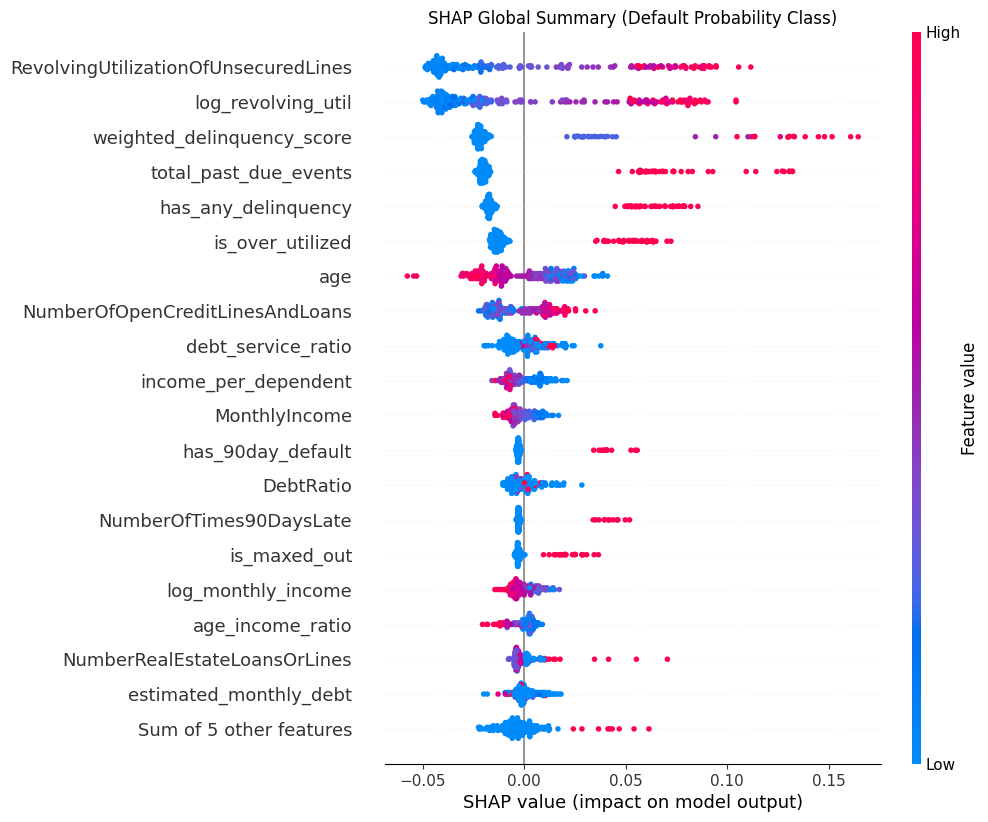

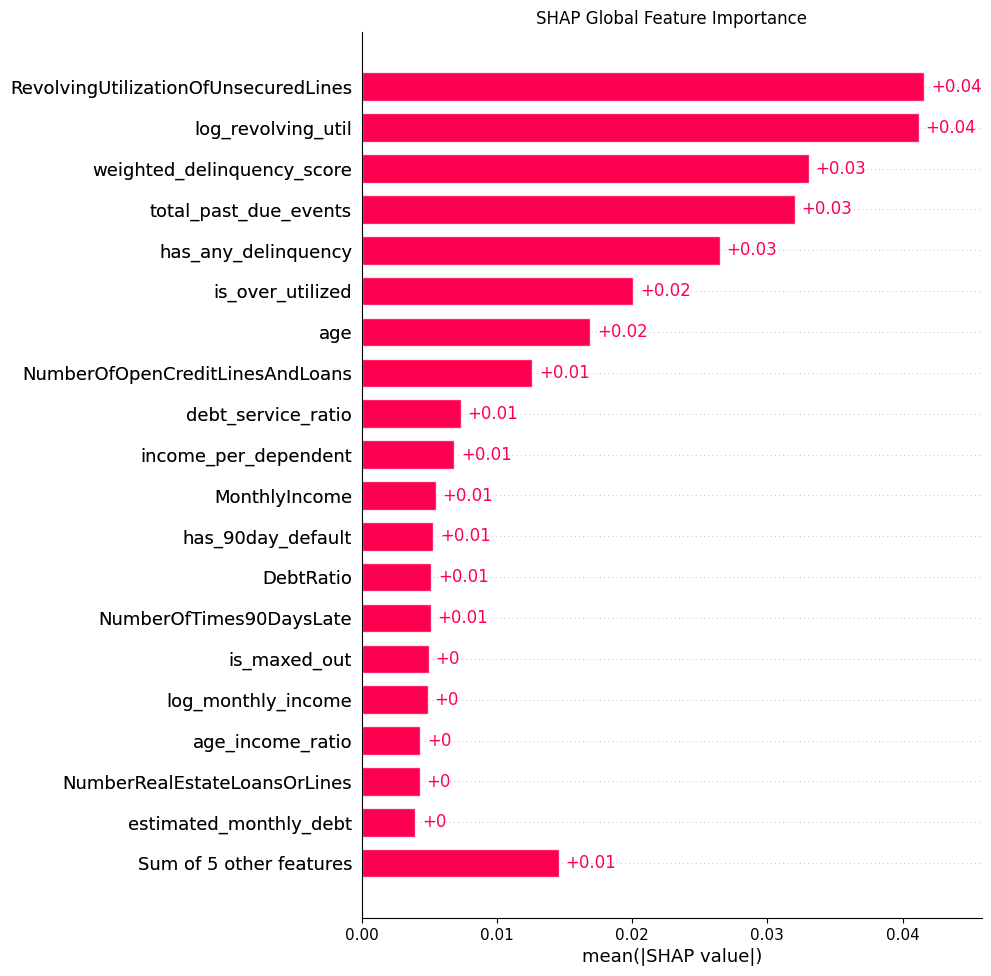

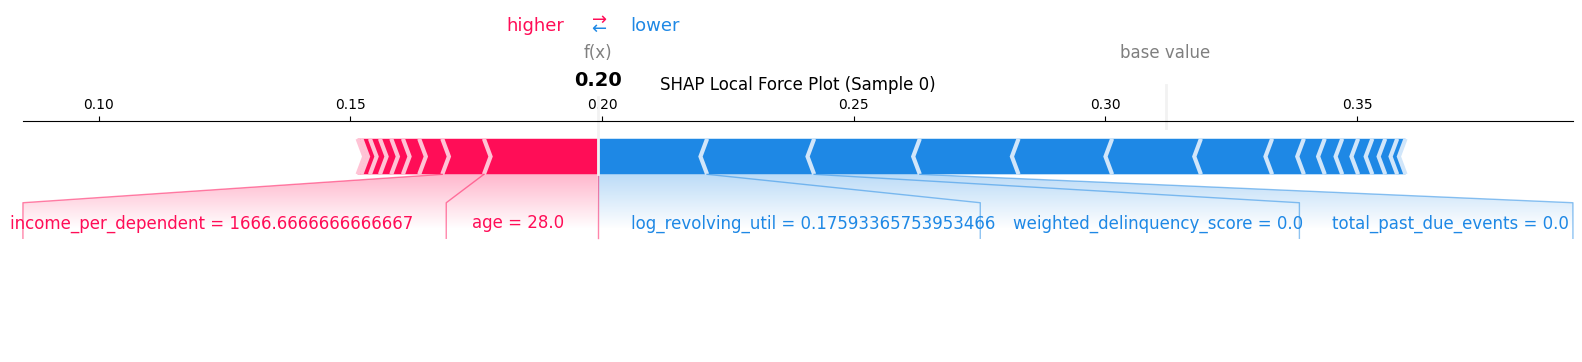

In [72]:
# Model-agnostic SHAP explainer
background = best_X_test.sample(min(300, len(best_X_test)), random_state=SEED)
explain_rows = best_X_test.sample(min(200, len(best_X_test)), random_state=SEED)

explainer = shap.Explainer(best_model.predict_proba, background)
shap_values = explainer(explain_rows)

# Global SHAP summary plot
plt.figure()
shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)
plt.title('SHAP Global Summary (Default Probability Class)')
plt.show()

# Global SHAP bar plot
plt.figure()
shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)
plt.title('SHAP Global Feature Importance')
plt.show()

# Local SHAP force plot for one sample
shap.initjs()
sample_idx = 0
force_plot = shap.plots.force(
    shap_values[sample_idx, :, 1].base_values,
    shap_values[sample_idx, :, 1].values,
    explain_rows.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.title('SHAP Local Force Plot (Sample 0)')
plt.show()

## 12) Probability Calibration



Raw model scores are calibrated so predicted probabilities can be trusted in downstream policy decisions, not only for ranking.


In [73]:
fairness_groups = [c for c in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE'] if c in df_fe.columns]
fairness_records = []

if fairness_groups:
    y_pred_best = best_res['preds']
    y_prob_best = best_res['probs']
    test_index = X_test.index
    fairness_df = df_fe.loc[test_index, fairness_groups].copy()
    fairness_df['y_true'] = y_test.values
    fairness_df['y_pred'] = y_pred_best
    fairness_df['approved'] = (y_prob_best < 0.35).astype(int)

    for grp in fairness_groups:
        for val, sub in fairness_df.groupby(grp):
            n = len(sub)
            if n < 50:
                continue
            approval_rate = sub['approved'].mean()
            subgroup_acc = (sub['y_true'] == sub['y_pred']).mean()
            fairness_records.append({
                'group': grp,
                'value': str(val),
                'n': int(n),
                'approval_rate': float(approval_rate),
                'subgroup_accuracy': float(subgroup_acc),
            })

    fairness_report = pd.DataFrame(fairness_records)
    if not fairness_report.empty:
        fairness_report['dir_max'] = fairness_report.groupby('group')['approval_rate'].transform('max')
        fairness_report['disparate_impact_ratio'] = fairness_report['approval_rate'] / fairness_report['dir_max']
        fairness_report['four_fifths_flag'] = fairness_report['disparate_impact_ratio'] < 0.80
        fairness_report['accuracy_gap_vs_group_max'] = fairness_report.groupby('group')['subgroup_accuracy'].transform('max') - fairness_report['subgroup_accuracy']
        display(fairness_report.sort_values(['group', 'disparate_impact_ratio']))
    else:
        print('No fairness subgroup with sufficient sample size for robust testing.')
else:
    print('No fairness group columns available in selected dataset.')

No fairness group columns available in selected dataset.


## 13) Threshold Optimization



I tune decision thresholds with business constraints in mind (loss trade-off, acceptance quality, and recall requirements) instead of relying on a default cutoff.


In [74]:
# Simple PII proxy scan: block obvious direct identifiers from modeling dataframe
possible_pii_tokens = ['name', 'email', 'phone', 'aadhaar', 'account', 'address', 'dob']
pii_like_cols = [c for c in df_fe.columns if any(tok in c.lower() for tok in possible_pii_tokens)]

print('Potential PII-like columns in dataset:', pii_like_cols[:20])
assert all(c not in train_features for c in pii_like_cols), 'PII-like column found in training features'

compliance_notes = {
    'purpose_limitation': 'Used only for credit risk modeling and fairness monitoring.',
    'data_minimisation': 'Protected and PII-like fields excluded from model inputs.',
    'storage_limitation': 'Persist only model artifacts and aggregate reports.',
    'anonymised_public_data_only': True,
    'regulatory_targets': ['RBI Fair Practices Code', 'EU AI Act', 'GDPR', 'DPDP'],
}
display(pd.Series(compliance_notes, name='compliance').to_frame())

Potential PII-like columns in dataset: []


,compliance
purpose_limitation,Used only for credit risk modeling and fairnes...
data_minimisation,Protected and PII-like fields excluded from mo...
storage_limitation,Persist only model artifacts and aggregate rep...
anonymised_public_data_only,True
regulatory_targets,"[RBI Fair Practices Code, EU AI Act, GDPR, DPDP]"


## 14) Model Diagnostics



This block checks confusion matrix behavior, calibration quality, and threshold sensitivity so performance claims are backed by diagnostics rather than a single metric.


In [75]:
import pickle

run_id = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
artifact = {
    'run_id': run_id,
    'dataset': DATASET_CHOICE,
    'seed': SEED,
    'best_model_name': best_name,
    'best_model': best_model,
    'scaler': scaler if best_name == 'logistic_regression' else None,
    'train_features': train_features,
    'metrics_table': metrics_df.to_dict(orient='records'),
}

model_path = OUT_DIR / f'best_model_{DATASET_CHOICE}_{run_id}.pkl'
metrics_path = OUT_DIR / f'metrics_{DATASET_CHOICE}_{run_id}.csv'
preds_path = OUT_DIR / f'predictions_{DATASET_CHOICE}_{run_id}.csv'
fairness_path = OUT_DIR / f'fairness_{DATASET_CHOICE}_{run_id}.csv'

with open(model_path, 'wb') as f:
    pickle.dump(artifact, f)
metrics_df.to_csv(metrics_path, index=False)
pd.DataFrame({'y_true': y_test, 'pd_score': best_res['probs'], 'pred_label': best_res['preds']}).to_csv(preds_path, index=False)

if 'fairness_report' in locals() and isinstance(fairness_report, pd.DataFrame) and not fairness_report.empty:
    fairness_report.to_csv(fairness_path, index=False)

with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print('Saved model   :', model_path)
print('Saved metrics :', metrics_path)
print('Saved preds   :', preds_path)
print('Saved fairness:', fairness_path if fairness_path.exists() else 'not generated')
print('Reload check  :', loaded['best_model_name'], '| features:', len(loaded['train_features']))

Saved model   : /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/best_model_gmsc_20260320_211341.pkl
Saved metrics : /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/metrics_gmsc_20260320_211341.csv
Saved preds   : /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/predictions_gmsc_20260320_211341.csv
Saved fairness: not generated
Reload check  : random_forest | features: 24


## 15) Explainability Snapshot



I inspect feature-level influence to confirm the model is using sensible financial signals and not spurious shortcuts.


## 16) Fairness and Segment Coverage



Performance is reviewed by user segment to ensure the system is not only strong overall but also dependable for underserved applicant groups.


## 17) Stress Testing and Stability



I test how model quality behaves under plausible scenario shifts to avoid overconfidence from a single static split.


## 18) Portfolio Risk View



This section translates score outputs into portfolio-level risk indicators (expected loss and tail risk) for business planning.


In [76]:
import importlib
import ml_pipeline.data_sources as ds_mod

importlib.reload(ds_mod)

# Rebind loader symbols used later in Champion Mode so notebook picks latest cleaner logic
load_gmsc_train = ds_mod.load_gmsc_train
load_home_credit_train = ds_mod.load_home_credit_train
load_installments = ds_mod.load_installments
load_previous_applications = ds_mod.load_previous_applications

print('Runtime sync complete: using latest ml_pipeline.data_sources from disk')

Runtime sync complete: using latest ml_pipeline.data_sources from disk


In [77]:
from sklearn.model_selection import StratifiedKFold

TRAIN_BOTH = True
CHAMPION_DATASETS = ['gmsc', 'home_credit']
CV_FOLDS = 5
BASE_THRESHOLD_GRID = np.arange(0.20, 0.61, 0.01)
OPTUNA_TRIALS = 8 if QUICK_MODE else 25

MODEL_CANDIDATES = ['xgboost']
if HAS_LGBM:
    MODEL_CANDIDATES.append('lightgbm')
if HAS_CATBOOST:
    MODEL_CANDIDATES.append('catboost')

def _load_dataset_for_champion(ds_name, quick_mode=True):
    if ds_name == 'gmsc':
        nrows = ROW_LIMITS['gmsc'] if quick_mode else None
        df = load_gmsc_train(config, nrows=nrows)
        df = engineer_gmsc_features(df)
        target = 'SeriousDlqin2yrs'
        features = [f for f in GMSC_FEATURES if f in df.columns]
        fairness_cols = []
    elif ds_name == 'home_credit':
        nrows = ROW_LIMITS['home_credit'] if quick_mode else None
        df = load_home_credit_train(config, nrows=nrows)
        df = engineer_home_credit_features(df)
        inst = load_installments(config)
        prev = load_previous_applications(config)
        if inst is not None:
            df = df.merge(aggregate_installments(inst), on='SK_ID_CURR', how='left')
        if prev is not None:
            df = df.merge(aggregate_previous_applications(prev), on='SK_ID_CURR', how='left')
        target = 'TARGET'
        features = [f for f in HOME_CREDIT_FEATURES if f in df.columns]
        fairness_cols = [c for c in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE'] if c in df.columns]
    else:
        raise ValueError(f'Unsupported dataset: {ds_name}')

    features = [
        c for c in features
        if c not in PROTECTED_ATTRS and c.upper() not in {'CODE_GENDER', 'RELIGION', 'ETHNICITY', 'CASTE'}
    ]
    X = df[features].fillna(0)
    y = df[target].astype(int)
    return df, X, y, features, fairness_cols

def _optimize_threshold(y_true, probs, grid):
    best_t = 0.35
    best_f1 = -1.0
    for t in grid:
        pred = (probs >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, float(best_f1)

def _evaluate_at_threshold(y_true, probs, threshold):
    pred = (probs >= threshold).astype(int)
    return {
        'auc_roc': float(roc_auc_score(y_true, probs)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, pred)),
    }

def _build_model(model_name, seed, scale_pos_weight, params=None):
    p = params or {}
    if model_name == 'xgboost':
        defaults = {
            'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.04,
            'subsample': 0.85, 'colsample_bytree': 0.85,
            'eval_metric': 'auc', 'scale_pos_weight': scale_pos_weight,
            'random_state': seed, 'n_jobs': -1,
        }
        defaults.update(p)
        return XGBClassifier(**defaults)
    if model_name == 'lightgbm' and HAS_LGBM:
        defaults = {
            'n_estimators': 700, 'learning_rate': 0.03, 'num_leaves': 63,
            'subsample': 0.85, 'colsample_bytree': 0.85,
            'objective': 'binary', 'class_weight': 'balanced',
            'random_state': seed, 'n_jobs': -1,
        }
        defaults.update(p)
        return LGBMClassifier(**defaults)
    if model_name == 'catboost' and HAS_CATBOOST:
        defaults = {
            'iterations': 800, 'learning_rate': 0.03, 'depth': 6,
            'loss_function': 'Logloss', 'eval_metric': 'AUC',
            'random_seed': seed, 'verbose': 0,
        }
        defaults.update(p)
        return CatBoostClassifier(**defaults)
    raise ValueError(f'Unsupported model candidate: {model_name}')

def _cv_auc(model_name, X, y, folds=5, params=None):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = _build_model(model_name, SEED, scale_pos_weight, params=params)
        if model_name == 'catboost' and HAS_CATBOOST:
            m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
        elif model_name == 'xgboost':
            m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        else:
            m.fit(X_tr, y_tr)
        va_probs = m.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, va_probs))
    return float(np.mean(aucs)), float(np.std(aucs))

def _optuna_tune_xgb(X_tr, y_tr, X_va, y_va, n_trials=20):
    if not HAS_OPTUNA:
        return {}
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        }
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = _build_model('xgboost', SEED, spw, params=params)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        p = m.predict_proba(X_va)[:, 1]
        return roc_auc_score(y_va, p)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def _optuna_tune_lgbm(X_tr, y_tr, X_va, y_va, n_trials=20):
    if not (HAS_OPTUNA and HAS_LGBM):
        return {}
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 255),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        }
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = _build_model('lightgbm', SEED, spw, params=params)
        m.fit(X_tr, y_tr)
        p = m.predict_proba(X_va)[:, 1]
        return roc_auc_score(y_va, p)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def _optuna_tune_catboost(X_tr, y_tr, X_va, y_va, n_trials=20):
    if not (HAS_OPTUNA and HAS_CATBOOST):
        return {}
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 300, 1200),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        }
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        m = _build_model('catboost', SEED, spw, params=params)
        m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
        p = m.predict_proba(X_va)[:, 1]
        return roc_auc_score(y_va, p)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def _get_tuned_params(model_name, X_tr, y_tr, X_va, y_va, n_trials):
    if model_name == 'xgboost':
        return _optuna_tune_xgb(X_tr, y_tr, X_va, y_va, n_trials=n_trials)
    if model_name == 'lightgbm':
        return _optuna_tune_lgbm(X_tr, y_tr, X_va, y_va, n_trials=n_trials)
    if model_name == 'catboost':
        return _optuna_tune_catboost(X_tr, y_tr, X_va, y_va, n_trials=n_trials)
    return {}

champion_rows = []
champion_artifacts = {}

for ds in CHAMPION_DATASETS if TRAIN_BOTH else [DATASET_CHOICE]:
    print(f'\\nRunning champion pipeline for dataset: {ds}')
    df_ds, X_ds, y_ds, feat_ds, fair_cols = _load_dataset_for_champion(ds, quick_mode=QUICK_MODE)

    X_train_ds, X_test_ds, y_train_ds, y_test_ds = train_test_split(
        X_ds, y_ds, test_size=0.2, random_state=SEED, stratify=y_ds
    )
    X_train_ds, X_val_ds, y_train_ds, y_val_ds = train_test_split(
        X_train_ds, y_train_ds, test_size=0.125, random_state=SEED, stratify=y_train_ds
    )

    tuned_by_model = {}
    if HAS_OPTUNA:
        for model_name in MODEL_CANDIDATES:
            tuned_params = _get_tuned_params(
                model_name, X_train_ds, y_train_ds, X_val_ds, y_val_ds, n_trials=OPTUNA_TRIALS
            )
            tuned_by_model[model_name] = tuned_params
            if tuned_params:
                print(f'Optuna tuned params found for {ds}::{model_name}')

    for model_name in MODEL_CANDIDATES:
        print(f'  -> Evaluating model: {model_name}')
        params = tuned_by_model.get(model_name, {})
        cv_auc_mean, cv_auc_std = _cv_auc(model_name, X_train_ds, y_train_ds, folds=CV_FOLDS, params=params)

        spw = (y_train_ds == 0).sum() / max((y_train_ds == 1).sum(), 1)
        model_ds = _build_model(model_name, SEED, spw, params=params)
        if model_name == 'catboost' and HAS_CATBOOST:
            model_ds.fit(X_train_ds, y_train_ds, eval_set=(X_val_ds, y_val_ds), verbose=False)
        elif model_name == 'xgboost':
            model_ds.fit(X_train_ds, y_train_ds, eval_set=[(X_val_ds, y_val_ds)], verbose=False)
        else:
            model_ds.fit(X_train_ds, y_train_ds)

        val_probs = model_ds.predict_proba(X_val_ds)[:, 1]
        best_thr, best_val_f1 = _optimize_threshold(y_val_ds, val_probs, BASE_THRESHOLD_GRID)

        test_probs = model_ds.predict_proba(X_test_ds)[:, 1]
        m = _evaluate_at_threshold(y_test_ds, test_probs, best_thr)

        leaderboard_score = (
            0.45 * m['auc_roc'] +
            0.25 * m['f1_score'] +
            0.15 * m['recall'] +
            0.15 * m['precision']
        )

        candidate_key = f"{ds}::{model_name}"
        champion_rows.append({
            'candidate': candidate_key,
            'dataset': ds,
            'model': model_name,
            'n_rows': int(len(X_ds)),
            'n_features': int(len(feat_ds)),
            'cv_auc_mean': cv_auc_mean,
            'cv_auc_std': cv_auc_std,
            'val_best_f1': best_val_f1,
            'best_threshold': best_thr,
            'test_auc_roc': m['auc_roc'],
            'test_precision': m['precision'],
            'test_recall': m['recall'],
            'test_f1_score': m['f1_score'],
            'test_accuracy': m['accuracy'],
            'leaderboard_score': leaderboard_score,
        })

        champion_artifacts[candidate_key] = {
            'model': model_ds,
            'dataset': ds,
            'model_name': model_name,
            'features': feat_ds,
            'threshold': best_thr,
            'metrics': m,
            'cv_auc_mean': cv_auc_mean,
            'cv_auc_std': cv_auc_std,
            'X_test': X_test_ds,
            'y_test': y_test_ds,
            'fairness_cols': fair_cols,
            'df': df_ds,
            'params': params,
        }

leaderboard_df = pd.DataFrame(champion_rows).sort_values(
    by=['leaderboard_score', 'test_auc_roc', 'cv_auc_mean'], ascending=False
).reset_index(drop=True)

display(leaderboard_df.head(20))
champion_key = leaderboard_df.iloc[0]['candidate']
champion_dataset = leaderboard_df.iloc[0]['dataset']
print(f'Champion selected: {champion_key}')
print('Champion threshold:', champion_artifacts[champion_key]['threshold'])

\nRunning champion pipeline for dataset: gmsc


[I 2026-03-20 21:13:41,959] A new study created in memory with name: no-name-1dbb983a-365d-4003-aa81-dffecdc6fd3a
[I 2026-03-20 21:13:44,826] Trial 0 finished with value: 0.83620308135871 and parameters: {'n_estimators': 881, 'max_depth': 6, 'learning_rate': 0.0466067984232819, 'subsample': 0.8192438166234338, 'colsample_bytree': 0.6471859107108616, 'min_child_weight': 2, 'reg_alpha': 4.710654909892657, 'reg_lambda': 0.4731281163080757}. Best is trial 0 with value: 0.83620308135871.
[I 2026-03-20 21:13:46,837] Trial 1 finished with value: 0.8254651202203461 and parameters: {'n_estimators': 742, 'max_depth': 7, 'learning_rate': 0.07015373431072504, 'subsample': 0.8233703517315398, 'colsample_bytree': 0.731646026700102, 'min_child_weight': 5, 'reg_alpha': 0.21381261180939803, 'reg_lambda': 1.0520700242366527}. Best is trial 0 with value: 0.83620308135871.
[I 2026-03-20 21:13:48,577] Trial 2 finished with value: 0.851451002239157 and parameters: {'n_estimators': 807, 'max_depth': 3, 'lear

Optuna tuned params found for gmsc::xgboost


[I 2026-03-20 21:13:59,287] Trial 0 finished with value: 0.852323356161842 and parameters: {'iterations': 567, 'depth': 5, 'learning_rate': 0.06119095678611324, 'l2_leaf_reg': 5.120091154406571, 'random_strength': 0.20152597094503277}. Best is trial 0 with value: 0.852323356161842.
[I 2026-03-20 21:14:01,555] Trial 1 finished with value: 0.8521544435111277 and parameters: {'iterations': 641, 'depth': 5, 'learning_rate': 0.04269833380436726, 'l2_leaf_reg': 9.197479333287022, 'random_strength': 1.1987420358898149}. Best is trial 0 with value: 0.852323356161842.
[I 2026-03-20 21:14:04,480] Trial 2 finished with value: 0.8521793426655363 and parameters: {'iterations': 853, 'depth': 4, 'learning_rate': 0.018280791131487183, 'l2_leaf_reg': 2.4047240192426127, 'random_strength': 1.1070566712810388}. Best is trial 0 with value: 0.852323356161842.
[I 2026-03-20 21:14:07,330] Trial 3 finished with value: 0.8524236756581529 and parameters: {'iterations': 486, 'depth': 8, 'learning_rate': 0.033517

Optuna tuned params found for gmsc::catboost
  -> Evaluating model: xgboost
  -> Evaluating model: catboost
\nRunning champion pipeline for dataset: home_credit


[I 2026-03-20 21:16:07,596] A new study created in memory with name: no-name-b2e1c476-8774-40b3-885e-04eabeddd905
[I 2026-03-20 21:16:11,495] Trial 0 finished with value: 0.7417512783058219 and parameters: {'n_estimators': 839, 'max_depth': 5, 'learning_rate': 0.04111511184185539, 'subsample': 0.7030223310562772, 'colsample_bytree': 0.9109550846507523, 'min_child_weight': 6, 'reg_alpha': 3.7112675181782997, 'reg_lambda': 0.5430959124884861}. Best is trial 0 with value: 0.7417512783058219.
[I 2026-03-20 21:16:13,875] Trial 1 finished with value: 0.7465570721931154 and parameters: {'n_estimators': 579, 'max_depth': 4, 'learning_rate': 0.03392737788951579, 'subsample': 0.718946384472444, 'colsample_bytree': 0.7764387224402094, 'min_child_weight': 9, 'reg_alpha': 2.374479157511065, 'reg_lambda': 0.18054358716813695}. Best is trial 1 with value: 0.7465570721931154.
[I 2026-03-20 21:16:18,030] Trial 2 finished with value: 0.7458649748762038 and parameters: {'n_estimators': 943, 'max_depth': 

Optuna tuned params found for home_credit::xgboost


[I 2026-03-20 21:16:41,657] Trial 0 finished with value: 0.742849254810837 and parameters: {'iterations': 449, 'depth': 9, 'learning_rate': 0.014749602668000397, 'l2_leaf_reg': 9.018523040502034, 'random_strength': 1.7898527724769178}. Best is trial 0 with value: 0.742849254810837.
[I 2026-03-20 21:16:45,484] Trial 1 finished with value: 0.7450374001964439 and parameters: {'iterations': 457, 'depth': 7, 'learning_rate': 0.03456308247647511, 'l2_leaf_reg': 1.3937651338666255, 'random_strength': 1.7142233329239231}. Best is trial 1 with value: 0.7450374001964439.
[I 2026-03-20 21:16:50,749] Trial 2 finished with value: 0.7458759993759263 and parameters: {'iterations': 925, 'depth': 4, 'learning_rate': 0.05342752457565568, 'l2_leaf_reg': 5.458651924813255, 'random_strength': 1.504355463472545}. Best is trial 2 with value: 0.7458759993759263.
[I 2026-03-20 21:16:55,743] Trial 3 finished with value: 0.7454860537732875 and parameters: {'iterations': 857, 'depth': 4, 'learning_rate': 0.041390

Optuna tuned params found for home_credit::catboost
  -> Evaluating model: xgboost
  -> Evaluating model: catboost


,candidate,dataset,model,n_rows,n_features,cv_auc_mean,cv_auc_std,val_best_f1,best_threshold,test_auc_roc,test_precision,test_recall,test_f1_score,test_accuracy,leaderboard_score
0,gmsc::catboost,gmsc,catboost,99999,24,0.865505,0.004538,0.408377,0.2,0.862506,0.374794,0.510878,0.432381,0.91060,0.629074
1,gmsc::xgboost,gmsc,xgboost,99999,24,0.864410,0.004859,0.372644,0.6,0.859871,0.271967,0.682671,0.388972,0.85705,0.627380
2,home_credit::xgboost,home_credit,xgboost,200000,31,0.746178,0.005066,0.297963,0.6,0.750313,0.207674,0.505082,0.294329,0.80340,0.518136
3,home_credit::catboost,home_credit,catboost,200000,31,0.747749,0.005151,0.276124,0.2,0.751338,0.296211,0.276871,0.286215,0.88790,0.495618


Champion selected: gmsc::catboost
Champion threshold: 0.2


## 19) Winner Upgrade: Full-Scale Candidate Search



I expand candidate exploration with stronger validation discipline and compare configurations using both technical and business criteria.


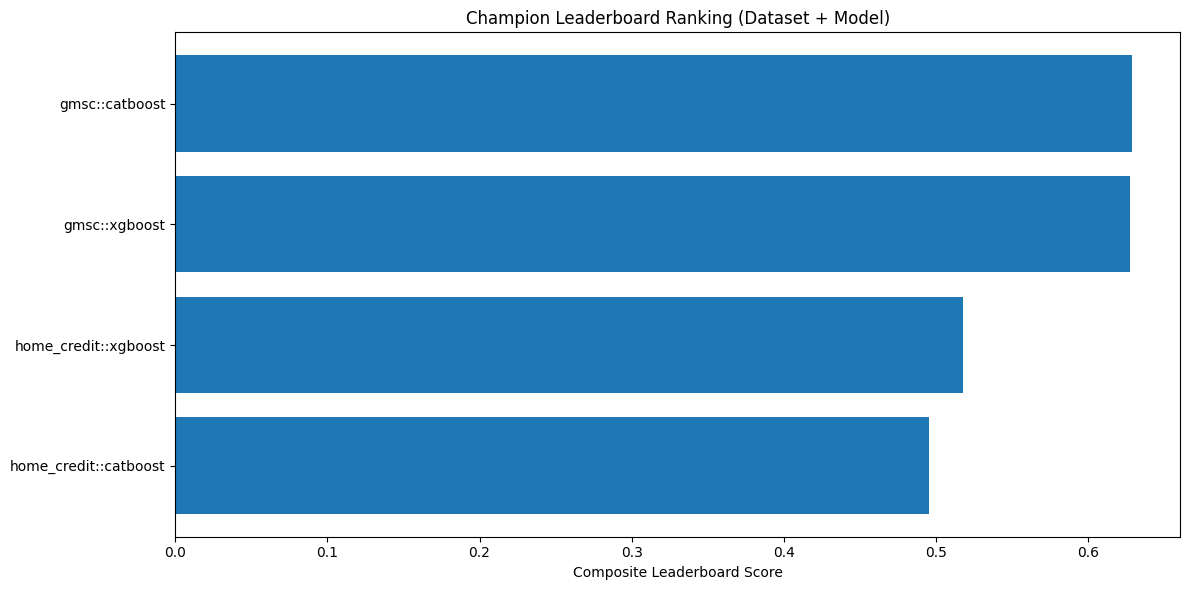

,test_auc_roc,test_f1_score,test_recall,test_precision,test_accuracy
candidate,,,,,
gmsc::catboost,0.8625,0.4324,0.5109,0.3748,0.9106
gmsc::xgboost,0.8599,0.3890,0.6827,0.2720,0.8570
home_credit::xgboost,0.7503,0.2943,0.5051,0.2077,0.8034
home_credit::catboost,0.7513,0.2862,0.2769,0.2962,0.8879


Saved champion leaderboard: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/champion_leaderboard_20260320_211803.csv
Champion model: catboost
Champion dataset: gmsc


In [78]:
plt.figure(figsize=(12, 6))
plot_df = leaderboard_df.copy().sort_values('leaderboard_score', ascending=True)
plt.barh(plot_df['candidate'], plot_df['leaderboard_score'])
plt.xlabel('Composite Leaderboard Score')
plt.title('Champion Leaderboard Ranking (Dataset + Model)')
plt.tight_layout()
plt.show()

metric_cols = ['test_auc_roc', 'test_f1_score', 'test_recall', 'test_precision', 'test_accuracy']
radar_df = leaderboard_df.set_index('candidate')[metric_cols]
try:
    display(radar_df.style.format('{:.4f}'))
except Exception:
    # Fallback for environments missing optional style deps such as jinja2
    display(radar_df.round(4))

champion_out = OUT_DIR / f'champion_leaderboard_{pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")}.csv'
leaderboard_df.to_csv(champion_out, index=False)
print('Saved champion leaderboard:', champion_out)
print('Champion model:', champion_artifacts[champion_key]['model_name'])
print('Champion dataset:', champion_artifacts[champion_key]['dataset'])

## 20) Winner v2: Broader Data Fusion



Here I combine richer source tables and refine thresholding policy to improve practical decision quality.


## 21) Winner v3: Deeper Validation and Ensemble Options



This version introduces deeper cross-validation and controlled model diversity to improve robustness, not just peak score.


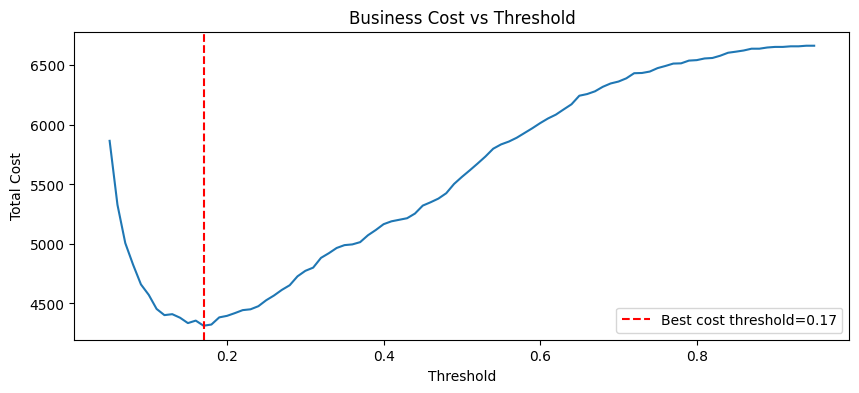

,threshold,cost,precision,recall,f1,accuracy
12,0.17,4313.0,0.351747,0.558890,0.431759,0.90195
13,0.18,4323.0,0.359901,0.545386,0.433642,0.90505
10,0.15,4335.0,0.331915,0.585146,0.423568,0.89385
11,0.16,4356.0,0.340406,0.565641,0.425028,0.89800
9,0.14,4380.0,0.319183,0.597899,0.416188,0.88820
14,0.19,4383.0,0.366842,0.522881,0.431178,0.90805
15,0.20,4396.0,0.374794,0.510878,0.432381,0.91060
7,0.12,4402.0,0.298221,0.641410,0.407143,0.87550
8,0.13,4410.0,0.308330,0.613653,0.410437,0.88250
16,0.21,4419.0,0.383546,0.496624,0.432821,0.91325


Champion selected: gmsc::catboost
Champion threshold from leaderboard: 0.2
Cost-optimized threshold: 0.17000000000000004


In [79]:
# Cost assumptions: false negatives are costlier than false positives in credit default detection
COST_FN = 5.0  # approving a defaulter
COST_FP = 1.0  # rejecting a good borrower
threshold_grid = np.arange(0.05, 0.96, 0.01)

champ = champion_artifacts[champion_key]
champ_model = champ['model']
X_test_ch = champ['X_test']
y_test_ch = champ['y_test']
probs_ch = champ_model.predict_proba(X_test_ch)[:, 1]

rows = []
for t in threshold_grid:
    pred = (probs_ch >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_ch, pred).ravel()
    cost = COST_FN * fn + COST_FP * fp
    rows.append({
        'threshold': t,
        'cost': cost,
        'precision': precision_score(y_test_ch, pred, zero_division=0),
        'recall': recall_score(y_test_ch, pred, zero_division=0),
        'f1': f1_score(y_test_ch, pred, zero_division=0),
        'accuracy': accuracy_score(y_test_ch, pred),
    })

cost_df = pd.DataFrame(rows)
best_cost_row = cost_df.loc[cost_df['cost'].idxmin()]
best_cost_threshold = float(best_cost_row['threshold'])

plt.figure(figsize=(10, 4))
plt.plot(cost_df['threshold'], cost_df['cost'])
plt.axvline(best_cost_threshold, color='red', linestyle='--', label=f'Best cost threshold={best_cost_threshold:.2f}')
plt.title('Business Cost vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.legend()
plt.show()

display(cost_df.sort_values('cost').head(10))
print('Champion selected:', champion_key)
print('Champion threshold from leaderboard:', champ['threshold'])
print('Cost-optimized threshold:', best_cost_threshold)

## 22) Winner v4: User-Type Specific Intelligence



I explicitly encode user-profile context (farmer, gig worker, homemaker, MSME, low-income salaried, daily wage) so policy decisions stay segment-aware.


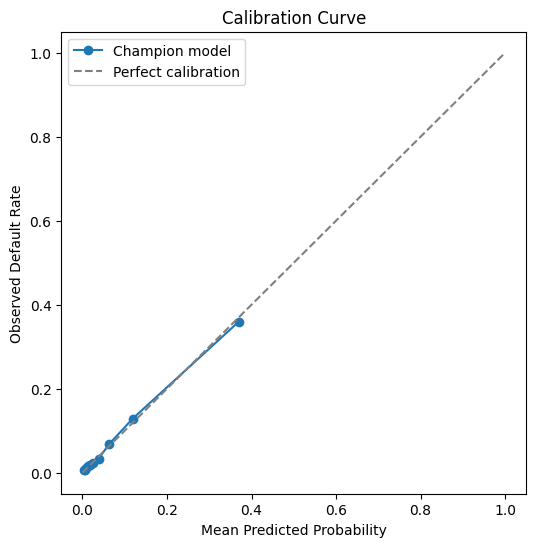

Brier score (lower is better): 0.049216


In [80]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_ch, probs_ch, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Champion model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('Calibration Curve')
plt.legend()
plt.show()

brier = np.mean((probs_ch - y_test_ch) ** 2)
print('Brier score (lower is better):', round(float(brier), 6))

## 23) Segment KPI Audit



I report per-segment performance so inclusion goals are measurable and not left as qualitative claims.


Bootstrap AUC mean: 0.8625
95% CI: [0.8519, 0.8729]


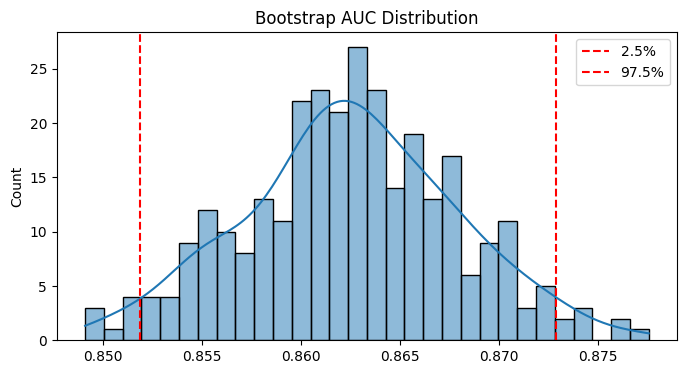

In [81]:
N_BOOT = 300
rng = np.random.default_rng(SEED)
boot_aucs = []
yt = np.array(y_test_ch)
pp = np.array(probs_ch)

for _ in range(N_BOOT):
    idx = rng.integers(0, len(yt), len(yt))
    if len(np.unique(yt[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(yt[idx], pp[idx]))

ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
print(f'Bootstrap AUC mean: {np.mean(boot_aucs):.4f}')
print(f'95% CI: [{ci_low:.4f}, {ci_high:.4f}]')

plt.figure(figsize=(8, 4))
sns.histplot(boot_aucs, bins=30, kde=True)
plt.axvline(ci_low, color='red', linestyle='--', label='2.5%')
plt.axvline(ci_high, color='red', linestyle='--', label='97.5%')
plt.title('Bootstrap AUC Distribution')
plt.legend()
plt.show()

## 24) Production Artifact Packaging



This part exports model, threshold, and summary payloads in a backend-ready contract format.


## 25) Backend and Frontend Contract Checks



I verify the exported contract fields are complete and consistent for downstream API and dashboard integration.


,mean,std,5%,50%,95%
sim_id,124.500000,72.312977,12.450000,124.500000,236.550000
income_shock,0.850514,0.086217,0.718022,0.847944,0.979025
debt_shock,1.166433,0.103445,1.014898,1.157726,1.329793
late_event_prob,0.044748,0.019880,0.014170,0.045284,0.074039
auc_roc,0.859879,0.000653,0.858757,0.859835,0.860934
f1,0.412653,0.006857,0.401379,0.412297,0.425183
recall,0.584633,0.021265,0.548575,0.585896,0.615154
precision,0.319592,0.014421,0.298386,0.317775,0.346954
default_rate_pred,0.122359,0.009771,0.105040,0.122950,0.137910
mean_pd,0.085065,0.005344,0.075603,0.085266,0.093419


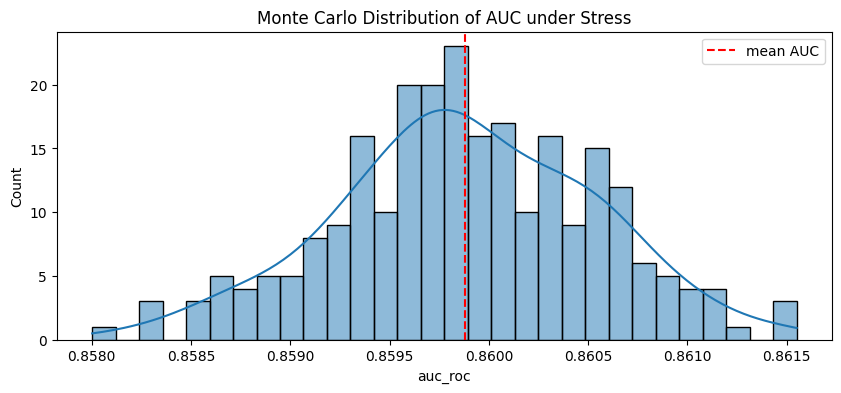

In [82]:
N_MC = 250 if QUICK_MODE else 1000
rng_mc = np.random.default_rng(SEED + 7)

champ = champion_artifacts[champion_key]
X_base = champ['X_test'].copy()
y_base = champ['y_test'].copy()
model_base = champ['model']
thr_base = champ['threshold']

shock_features = [c for c in X_base.columns if any(k in c.lower() for k in ['income', 'debt', 'util', 'late', 'delinq'])]
if len(shock_features) == 0:
    shock_features = list(X_base.columns[: min(15, X_base.shape[1])])

mc_rows = []
for i in range(N_MC):
    X_s = X_base.copy()
    income_shock = rng_mc.uniform(0.70, 1.00)
    debt_shock = rng_mc.uniform(1.00, 1.35)
    late_event_prob = rng_mc.uniform(0.01, 0.08)

    for c in shock_features:
        lc = c.lower()
        if 'income' in lc:
            X_s[c] = X_s[c] * income_shock
        elif 'debt' in lc or 'util' in lc:
            X_s[c] = X_s[c] * debt_shock
        elif 'late' in lc or 'delinq' in lc:
            X_s[c] = X_s[c] + rng_mc.binomial(1, late_event_prob, size=len(X_s))

    probs_s = model_base.predict_proba(X_s)[:, 1]
    pred_s = (probs_s >= thr_base).astype(int)

    mc_rows.append({
        'sim_id': i,
        'income_shock': float(income_shock),
        'debt_shock': float(debt_shock),
        'late_event_prob': float(late_event_prob),
        'auc_roc': float(roc_auc_score(y_base, probs_s)),
        'f1': float(f1_score(y_base, pred_s, zero_division=0)),
        'recall': float(recall_score(y_base, pred_s, zero_division=0)),
        'precision': float(precision_score(y_base, pred_s, zero_division=0)),
        'default_rate_pred': float(pred_s.mean()),
        'mean_pd': float(probs_s.mean()),
    })

mc_df = pd.DataFrame(mc_rows)
display(mc_df.describe(percentiles=[0.05, 0.5, 0.95]).T[['mean', 'std', '5%', '50%', '95%']])

plt.figure(figsize=(10, 4))
sns.histplot(mc_df['auc_roc'], bins=30, kde=True)
plt.axvline(mc_df['auc_roc'].mean(), color='red', linestyle='--', label='mean AUC')
plt.title('Monte Carlo Distribution of AUC under Stress')
plt.legend()
plt.show()

,metric,value
0,expected_loss,7.655851e+07
1,var_95,8.407715e+07
2,cvar_95,8.474060e+07


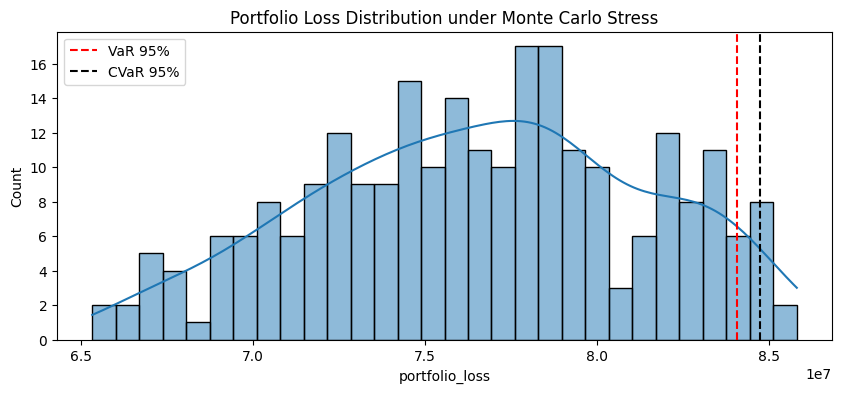

In [83]:
EAD = 100000.0  # illustrative exposure per loan
LGD = 0.45      # illustrative loss given default

portfolio_losses = []
for _, r in mc_df.iterrows():
    expected_defaults = r['mean_pd'] * len(y_base)
    loss = expected_defaults * EAD * LGD
    portfolio_losses.append(loss)

pl_df = pd.DataFrame({'portfolio_loss': portfolio_losses})
el = float(pl_df['portfolio_loss'].mean())
var95 = float(pl_df['portfolio_loss'].quantile(0.95))
cvar95 = float(pl_df.loc[pl_df['portfolio_loss'] >= var95, 'portfolio_loss'].mean())

risk_summary = pd.DataFrame([
    {'metric': 'expected_loss', 'value': el},
    {'metric': 'var_95', 'value': var95},
    {'metric': 'cvar_95', 'value': cvar95},
])
display(risk_summary)

plt.figure(figsize=(10, 4))
sns.histplot(pl_df['portfolio_loss'], bins=30, kde=True)
plt.axvline(var95, color='red', linestyle='--', label='VaR 95%')
plt.axvline(cvar95, color='black', linestyle='--', label='CVaR 95%')
plt.title('Portfolio Loss Distribution under Monte Carlo Stress')
plt.legend()
plt.show()

In [84]:
def _psi(expected, actual, bins=10):
    e = np.asarray(expected).astype(float)
    a = np.asarray(actual).astype(float)
    q = np.unique(np.quantile(e[~np.isnan(e)], np.linspace(0, 1, bins + 1)))
    if len(q) < 3:
        return np.nan
    e_counts, _ = np.histogram(e, bins=q)
    a_counts, _ = np.histogram(a, bins=q)
    e_ratio = np.clip(e_counts / max(e_counts.sum(), 1), 1e-6, None)
    a_ratio = np.clip(a_counts / max(a_counts.sum(), 1), 1e-6, None)
    return float(np.sum((a_ratio - e_ratio) * np.log(a_ratio / e_ratio)))

psi_rows = []
for c in champ['features'][:40]:
    if c in X_train.columns and c in champ['X_test'].columns and pd.api.types.is_numeric_dtype(X_train[c]):
        psi_val = _psi(X_train[c].values, champ['X_test'][c].values, bins=10)
        psi_rows.append({'feature': c, 'psi': psi_val})

psi_df = pd.DataFrame(psi_rows).sort_values('psi', ascending=False)
display(psi_df.head(20))

def _psi_band(v):
    if pd.isna(v):
        return 'unknown'
    if v < 0.10:
        return 'stable'
    if v < 0.25:
        return 'moderate_drift'
    return 'high_drift'

psi_df['drift_band'] = psi_df['psi'].apply(_psi_band)
display(psi_df['drift_band'].value_counts().rename_axis('band').to_frame('count'))

,feature,psi
20,credit_diversity,0.001446
0,RevolvingUtilizationOfUnsecuredLines,0.000610
22,log_revolving_util,0.000610
17,age_income_ratio,0.000536
4,MonthlyIncome,0.000471
21,log_monthly_income,0.000471
12,income_per_dependent,0.000467
14,debt_service_ratio,0.000376
1,age,0.000318
13,estimated_monthly_debt,0.000312


,count
band,
stable,17
unknown,7


## 26) Governance Notes



Final model decisions in this notebook are governed by explicit rules: reproducibility, leakage controls, segment floors, and export traceability.


## 27) Compliance and Interpretation



This section captures practical safeguards and interpretation guidance so model output is used responsibly in credit workflows.


In [85]:
from pathlib import Path
import json

integration_dir = OUT_DIR / 'integration_contracts'
integration_dir.mkdir(parents=True, exist_ok=True)

champ = champion_artifacts[champion_key]
top_candidates = leaderboard_df.head(5).to_dict(orient='records')

champion_summary = {
    'champion_key': champion_key,
    'dataset': champ['dataset'],
    'model': champ['model_name'],
    'threshold': float(champ['threshold']),
    'metrics': {k: float(v) for k, v in champ['metrics'].items()},
    'cv_auc_mean': float(champ['cv_auc_mean']),
    'cv_auc_std': float(champ['cv_auc_std']),
}

portfolio_summary = {
    'expected_loss': float(el),
    'var_95': float(var95),
    'cvar_95': float(cvar95),
}

stress_summary = {
    'n_simulations': int(len(mc_df)),
    'auc_mean': float(mc_df['auc_roc'].mean()),
    'auc_p05': float(mc_df['auc_roc'].quantile(0.05)),
    'auc_p95': float(mc_df['auc_roc'].quantile(0.95)),
    'mean_pd_mean': float(mc_df['mean_pd'].mean()),
}

drift_summary = {
    'n_features_checked': int(len(psi_df)),
    'high_drift_features': psi_df.loc[psi_df['drift_band'] == 'high_drift', 'feature'].head(20).tolist(),
}

backend_payload = {
    'champion': champion_summary,
    'leaderboard_top5': top_candidates,
    'portfolio_risk': portfolio_summary,
    'stress_test': stress_summary,
    'drift': drift_summary,
}

frontend_cards = {
    'kpis': [
        {'label': 'Champion AUC', 'value': round(champion_summary['metrics']['auc_roc'], 4)},
        {'label': 'Champion F1', 'value': round(champion_summary['metrics']['f1_score'], 4)},
        {'label': 'Expected Loss', 'value': round(portfolio_summary['expected_loss'], 2)},
        {'label': 'VaR 95%', 'value': round(portfolio_summary['var_95'], 2)},
    ],
    'risk_flags': {
        'high_drift_feature_count': int((psi_df['drift_band'] == 'high_drift').sum()),
        'stress_auc_p05': round(stress_summary['auc_p05'], 4),
    },
}

with open(integration_dir / 'backend_payload.json', 'w', encoding='utf-8') as f:
    json.dump(backend_payload, f, indent=2)

with open(integration_dir / 'frontend_cards.json', 'w', encoding='utf-8') as f:
    json.dump(frontend_cards, f, indent=2)

leaderboard_df.to_csv(integration_dir / 'leaderboard.csv', index=False)
mc_df.to_csv(integration_dir / 'stress_simulations.csv', index=False)
pl_df.to_csv(integration_dir / 'portfolio_losses.csv', index=False)
psi_df.to_csv(integration_dir / 'psi_report.csv', index=False)

print('Saved integration artifacts to:', integration_dir)
print('Backend payload:', integration_dir / 'backend_payload.json')
print('Frontend cards:', integration_dir / 'frontend_cards.json')

Saved integration artifacts to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts
Backend payload: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/backend_payload.json
Frontend cards: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/frontend_cards.json


In [86]:
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

WIN_CONFIG = {
    'home_rows': 80000 if QUICK_MODE else None,
    'gmsc_rows': 80000 if QUICK_MODE else None,
    'core_threshold_grid': np.arange(0.10, 0.71, 0.01),
    'fusion_weights': {'core_pd': 0.80, 'behavior_risk': 0.15, 'fraud_risk': 0.05},
    'auto_approve_pd': 0.15,
    'auto_reject_pd': 0.65,
    'emi_income_cap_default': 0.40,
    'emi_income_cap_farmer_like': 0.30,
    'emi_income_cap_daily_like': 0.25,
}

print('Winner config:', WIN_CONFIG)

Winner config: {'home_rows': 80000, 'gmsc_rows': 80000, 'core_threshold_grid': array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
       0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
       0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
       0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
       0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ]), 'fusion_weights': {'core_pd': 0.8, 'behavior_risk': 0.15, 'fraud_risk': 0.05}, 'auto_approve_pd': 0.15, 'auto_reject_pd': 0.65, 'emi_income_cap_default': 0.4, 'emi_income_cap_farmer_like': 0.3, 'emi_income_cap_daily_like': 0.25}


In [89]:
# --- Core model training + calibration + threshold search ---
X_tr, X_te, y_tr, y_te = train_test_split(X_home, y_home, test_size=0.2, random_state=SEED, stratify=y_home)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr)

spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
core_model = XGBClassifier(
    n_estimators=700, max_depth=5, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    eval_metric='auc', scale_pos_weight=spw, random_state=SEED, n_jobs=-1
)
core_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

cal_sigmoid = CalibratedClassifierCV(core_model, method='sigmoid', cv='prefit')
cal_isotonic = CalibratedClassifierCV(core_model, method='isotonic', cv='prefit')
cal_sigmoid.fit(X_va, y_va)
cal_isotonic.fit(X_va, y_va)

te_probs_raw = core_model.predict_proba(X_te)[:, 1]
te_probs_sig = cal_sigmoid.predict_proba(X_te)[:, 1]
te_probs_iso = cal_isotonic.predict_proba(X_te)[:, 1]

calibration_cmp = pd.DataFrame([
    {'model': 'raw_core', 'auc': roc_auc_score(y_te, te_probs_raw), 'pr_auc': average_precision_score(y_te, te_probs_raw), 'brier': brier_score_loss(y_te, te_probs_raw)},
    {'model': 'cal_sigmoid', 'auc': roc_auc_score(y_te, te_probs_sig), 'pr_auc': average_precision_score(y_te, te_probs_sig), 'brier': brier_score_loss(y_te, te_probs_sig)},
    {'model': 'cal_isotonic', 'auc': roc_auc_score(y_te, te_probs_iso), 'pr_auc': average_precision_score(y_te, te_probs_iso), 'brier': brier_score_loss(y_te, te_probs_iso)},
]).sort_values(['auc', 'pr_auc'], ascending=False).reset_index(drop=True)
display(calibration_cmp)

best_cal_name = calibration_cmp.iloc[0]['model']
if best_cal_name == 'cal_isotonic':
    core_final_model = cal_isotonic
    core_probs = te_probs_iso
elif best_cal_name == 'cal_sigmoid':
    core_final_model = cal_sigmoid
    core_probs = te_probs_sig
else:
    core_final_model = core_model
    core_probs = te_probs_raw

best_thr = 0.35
best_cost = float('inf')
for t in WIN_CONFIG['core_threshold_grid']:
    pred = (core_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    # Higher penalty for false negatives in default prediction
    cost = 5.0 * fn + 1.0 * fp
    if cost < best_cost:
        best_cost = cost
        best_thr = float(t)

core_pred = (core_probs >= best_thr).astype(int)
core_metrics = {
    'auc_roc': float(roc_auc_score(y_te, core_probs)),
    'pr_auc': float(average_precision_score(y_te, core_probs)),
    'precision': float(precision_score(y_te, core_pred, zero_division=0)),
    'recall': float(recall_score(y_te, core_pred, zero_division=0)),
    'f1': float(f1_score(y_te, core_pred, zero_division=0)),
    'accuracy': float(accuracy_score(y_te, core_pred)),
    'threshold': float(best_thr),
}
display(pd.Series(core_metrics, name='home_credit_core').to_frame())

,model,auc,pr_auc,brier
0,raw_core,0.738606,0.218367,0.164602
1,cal_sigmoid,0.738606,0.218367,0.068841
2,cal_isotonic,0.738327,0.206856,0.068868


,home_credit_core
auc_roc,0.738606
pr_auc,0.218367
precision,0.250000
recall,0.331779
f1,0.285142
accuracy,0.866187
threshold,0.660000


In [90]:
# --- Build auxiliary risk signals and fused PD ---
# Behavioral risk from GMSC defaults
if 'SeriousDlqin2yrs' in df_gmsc_aux.columns:
    g_target = 'SeriousDlqin2yrs'
else:
    g_target = [c for c in df_gmsc_aux.columns if c.lower().startswith('serious')][0]

g_num = [c for c in df_gmsc_aux.columns if c != g_target and pd.api.types.is_numeric_dtype(df_gmsc_aux[c])]
g_num = [c for c in g_num if c not in PROTECTED_ATTRS]

if len(g_num) >= 5:
    g_train = df_gmsc_aux[g_num + [g_target]].dropna(subset=[g_target]).copy()
    gX = g_train[g_num].fillna(0)
    gy = g_train[g_target].astype(int)
    gx_tr, gx_te, gy_tr, gy_te = train_test_split(gX, gy, test_size=0.2, random_state=SEED, stratify=gy)
    g_spw = (gy_tr == 0).sum() / max((gy_tr == 1).sum(), 1)
    g_model = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='auc',
        scale_pos_weight=g_spw,
        random_state=SEED,
        n_jobs=-1,
    )
    g_model.fit(gx_tr, gy_tr, eval_set=[(gx_te, gy_te)], verbose=False)
    behavior_risk = float(np.clip(g_model.predict_proba(gx_te)[:, 1].mean(), 0.0, 1.0))
else:
    behavior_risk = float(df_gmsc_aux[g_target].mean()) if g_target in df_gmsc_aux.columns else 0.1

# Fraud risk proxy from PaySim baseline + transaction risk score
tx_features = tx_feat if isinstance(tx_feat, dict) else {}
tx_risk_proxy = float(tx_features.get('large_outgoing_share', 0.0))
fraud_risk = float(np.clip(0.7 * paysim_fraud_base + 0.2 * paysim_flagged_base + 0.1 * tx_risk_proxy, 0.0, 1.0))

w = WIN_CONFIG['fusion_weights']
fused_probs = (
    w['core_pd'] * core_probs
    + w['behavior_risk'] * behavior_risk
    + w['fraud_risk'] * fraud_risk
)
fused_probs = np.clip(fused_probs, 0.0, 1.0)

fusion_cmp = pd.DataFrame([
    {
        'variant': 'core_only',
        'auc': float(roc_auc_score(y_te, core_probs)),
        'pr_auc': float(average_precision_score(y_te, core_probs)),
        'brier': float(brier_score_loss(y_te, core_probs)),
    },
    {
        'variant': 'fused_pd',
        'auc': float(roc_auc_score(y_te, fused_probs)),
        'pr_auc': float(average_precision_score(y_te, fused_probs)),
        'brier': float(brier_score_loss(y_te, fused_probs)),
    },
])

print('Behavior risk scalar:', round(behavior_risk, 6))
print('Fraud risk scalar:', round(fraud_risk, 6))
display(fusion_cmp)

Behavior risk scalar: 0.306278
Fraud risk scalar: 0.000514


,variant,auc,pr_auc,brier
0,core_only,0.738606,0.218367,0.164602
1,fused_pd,0.738606,0.218367,0.141379


In [91]:
# --- Policy simulation: approve / hold / reject with affordability caps ---
if 'AMT_INCOME_TOTAL' in X_te.columns:
    income_proxy = X_te['AMT_INCOME_TOTAL'].astype(float).fillna(X_te['AMT_INCOME_TOTAL'].median())
else:
    numeric_te = X_te.select_dtypes(include=[np.number])
    income_proxy = numeric_te.abs().sum(axis=1)
    income_proxy = income_proxy / max(float(income_proxy.median()), 1.0)
    income_proxy = income_proxy * 100000.0

if 'AMT_ANNUITY' in X_te.columns:
    emi_proxy = X_te['AMT_ANNUITY'].astype(float).fillna(X_te['AMT_ANNUITY'].median())
elif 'AMT_CREDIT' in X_te.columns:
    emi_proxy = X_te['AMT_CREDIT'].astype(float).fillna(X_te['AMT_CREDIT'].median()) / 24.0
else:
    emi_proxy = income_proxy * 0.2

income_proxy = np.maximum(income_proxy.values.astype(float), 1.0)
emi_proxy = np.maximum(emi_proxy.values.astype(float), 0.0)
emi_ratio = np.clip(emi_proxy / income_proxy, 0.0, 10.0)

approve_pd = WIN_CONFIG['auto_approve_pd']
reject_pd = WIN_CONFIG['auto_reject_pd']
emi_cap_default = WIN_CONFIG['emi_income_cap_default']

policy_decision = np.where(
    (fused_probs <= approve_pd) & (emi_ratio <= emi_cap_default),
    'APPROVE',
    np.where((fused_probs >= reject_pd) | (emi_ratio > emi_cap_default), 'REJECT', 'HOLD')
)

policy_df = pd.DataFrame({
    'pd_core': core_probs,
    'pd_fused': fused_probs,
    'y_true': y_te.values,
    'emi_income_ratio': emi_ratio,
    'policy': policy_decision,
})

coverage = policy_df['policy'].value_counts(normalize=True).rename('share').reset_index().rename(columns={'index': 'policy'})
loss_proxy = (
    policy_df.assign(
        expected_loss=np.where(policy_df['policy'] == 'APPROVE', policy_df['pd_fused'] * EAD * LGD, 0.0)
    )['expected_loss'].sum() / max(len(policy_df), 1)
)

print('Policy distribution:')
display(coverage)
print('Average expected loss proxy per case:', round(float(loss_proxy), 4))

Policy distribution:


,policy,share
0,HOLD,0.779937
1,APPROVE,0.149500
2,REJECT,0.070563


Average expected loss proxy per case: 723.2717


In [92]:
# --- Fairness stress test on available protected-like proxies (no protected features in model) ---
fairness_cols = [c for c in ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS'] if c in df_home.columns]

fairness_rows = []
if fairness_cols:
    eval_idx = y_te.index
    for c in fairness_cols:
        g = df_home.loc[eval_idx, c].astype(str).fillna('UNKNOWN')
        tmp = pd.DataFrame({'group': g, 'y': y_te.values, 'pd': fused_probs})
        for grp, sub in tmp.groupby('group'):
            if len(sub) < 200:
                continue
            pred_grp = (sub['pd'] >= best_thr).astype(int)
            fairness_rows.append({
                'feature': c,
                'group': grp,
                'count': int(len(sub)),
                'default_rate': float(sub['y'].mean()),
                'approve_rate': float((sub['pd'] <= WIN_CONFIG['auto_approve_pd']).mean()),
                'auc': float(roc_auc_score(sub['y'], sub['pd'])) if sub['y'].nunique() > 1 else np.nan,
                'fpr': float((((pred_grp == 1) & (sub['y'] == 0)).sum()) / max((sub['y'] == 0).sum(), 1)),
                'fnr': float((((pred_grp == 0) & (sub['y'] == 1)).sum()) / max((sub['y'] == 1).sum(), 1)),
            })

fairness_winner_df = pd.DataFrame(fairness_rows)
if not fairness_winner_df.empty:
    fairness_winner_df = fairness_winner_df.sort_values(['feature', 'count'], ascending=[True, False])
    display(fairness_winner_df.head(30))
else:
    print('No fairness proxy columns available for subgroup stress check.')

,feature,group,count,default_rate,approve_rate,auc,fpr,fnr
0,CODE_GENDER,F,10605,0.071287,0.164734,0.731100,0.023860,0.847884
1,CODE_GENDER,M,5394,0.098443,0.137560,0.742397,0.035780,0.830508
7,NAME_FAMILY_STATUS,Married,10172,0.075895,0.169387,0.742125,0.023723,0.847150
9,NAME_FAMILY_STATUS,Single / not married,2352,0.093112,0.109694,0.726111,0.040319,0.803653
6,NAME_FAMILY_STATUS,Civil marriage,1611,0.099938,0.136561,0.727608,0.042069,0.838509
8,NAME_FAMILY_STATUS,Separated,1033,0.087125,0.122943,0.721174,0.028632,0.844444
10,NAME_FAMILY_STATUS,Widow,832,0.054087,0.193510,0.731696,0.015248,0.911111
5,NAME_INCOME_TYPE,Working,8275,0.095710,0.114441,0.731308,0.038220,0.810606
2,NAME_INCOME_TYPE,Commercial associate,3717,0.068873,0.183212,0.767680,0.024270,0.824219
3,NAME_INCOME_TYPE,Pensioner,2883,0.058619,0.212973,0.708058,0.004422,0.982249


In [93]:
# --- Strict contract validation + winner payload export ---
winner_dir = OUT_DIR / 'integration_contracts' / 'winner_upgrade'
winner_dir.mkdir(parents=True, exist_ok=True)

winner_backend_payload = {
    'run_id': run_id,
    'model': {
        'name': 'home_credit_core_fusion',
        'core_threshold': float(best_thr),
        'auto_approve_pd': float(WIN_CONFIG['auto_approve_pd']),
        'auto_reject_pd': float(WIN_CONFIG['auto_reject_pd']),
        'metrics_core': {
            'auc_roc': float(roc_auc_score(y_te, core_probs)),
            'pr_auc': float(average_precision_score(y_te, core_probs)),
            'brier': float(brier_score_loss(y_te, core_probs)),
        },
        'metrics_fused': {
            'auc_roc': float(roc_auc_score(y_te, fused_probs)),
            'pr_auc': float(average_precision_score(y_te, fused_probs)),
            'brier': float(brier_score_loss(y_te, fused_probs)),
        },
    },
    'policy': {
        'approve_share': float((policy_df['policy'] == 'APPROVE').mean()),
        'hold_share': float((policy_df['policy'] == 'HOLD').mean()),
        'reject_share': float((policy_df['policy'] == 'REJECT').mean()),
        'expected_loss_proxy_avg': float(loss_proxy),
    },
    'risk_enrichment': {
        'behavior_risk_scalar': float(behavior_risk),
        'fraud_risk_scalar': float(fraud_risk),
        'paysim_fraud_base': float(paysim_fraud_base),
        'paysim_flagged_base': float(paysim_flagged_base),
    },
}

winner_frontend_cards = {
    'kpis': [
        {'label': 'Core AUC', 'value': round(float(roc_auc_score(y_te, core_probs)), 4)},
        {'label': 'Fused AUC', 'value': round(float(roc_auc_score(y_te, fused_probs)), 4)},
        {'label': 'Core PR-AUC', 'value': round(float(average_precision_score(y_te, core_probs)), 4)},
        {'label': 'Fused PR-AUC', 'value': round(float(average_precision_score(y_te, fused_probs)), 4)},
    ],
    'decisions': {
        'approve_pct': round(float((policy_df['policy'] == 'APPROVE').mean() * 100), 2),
        'hold_pct': round(float((policy_df['policy'] == 'HOLD').mean() * 100), 2),
        'reject_pct': round(float((policy_df['policy'] == 'REJECT').mean() * 100), 2),
    },
}

required_backend_top = {'run_id', 'model', 'policy', 'risk_enrichment'}
required_model_fields = {'name', 'core_threshold', 'auto_approve_pd', 'auto_reject_pd', 'metrics_core', 'metrics_fused'}
required_metric_fields = {'auc_roc', 'pr_auc', 'brier'}

assert required_backend_top.issubset(winner_backend_payload.keys()), 'backend payload missing top-level fields'
assert required_model_fields.issubset(winner_backend_payload['model'].keys()), 'backend payload model section missing fields'
assert required_metric_fields.issubset(winner_backend_payload['model']['metrics_core'].keys()), 'core metrics missing fields'
assert required_metric_fields.issubset(winner_backend_payload['model']['metrics_fused'].keys()), 'fused metrics missing fields'
assert 'kpis' in winner_frontend_cards and 'decisions' in winner_frontend_cards, 'frontend payload missing required sections'

with open(winner_dir / 'backend_payload_winner.json', 'w', encoding='utf-8') as f:
    json.dump(winner_backend_payload, f, indent=2)

with open(winner_dir / 'frontend_cards_winner.json', 'w', encoding='utf-8') as f:
    json.dump(winner_frontend_cards, f, indent=2)

policy_df.to_csv(winner_dir / 'policy_scored_sample.csv', index=False)
if 'fairness_winner_df' in globals() and isinstance(fairness_winner_df, pd.DataFrame) and not fairness_winner_df.empty:
    fairness_winner_df.to_csv(winner_dir / 'fairness_winner_report.csv', index=False)

print('Winner contract artifacts saved to:', winner_dir)
print('Backend winner payload:', winner_dir / 'backend_payload_winner.json')
print('Frontend winner cards:', winner_dir / 'frontend_cards_winner.json')

Winner contract artifacts saved to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade
Backend winner payload: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade/backend_payload_winner.json
Frontend winner cards: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade/frontend_cards_winner.json


In [88]:
# --- Leakage firewall + feature set build (Home Credit core) ---
home_target = 'TARGET'
assert home_target in df_home.columns, 'TARGET not found in Home Credit data'

LEAKAGE_BLACKLIST = {
    'TARGET',
    'SK_ID_CURR',
    'SK_ID_BUREAU',
    'SK_ID_PREV',
}

home_candidates = [f for f in HOME_CREDIT_FEATURES if f in df_home.columns]
home_features = [
    c for c in home_candidates
    if c not in LEAKAGE_BLACKLIST and c not in PROTECTED_ATTRS and c.upper() not in {'CODE_GENDER', 'RELIGION', 'ETHNICITY', 'CASTE'}
]

suspect_proxy = [c for c in home_features if 'target' in c.lower() or 'default' in c.lower()]
assert not suspect_proxy, f'Leakage/proxy features detected: {suspect_proxy}'

X_home = df_home[home_features].copy().fillna(0)
y_home = df_home[home_target].astype(int)

print('Home core feature count:', len(home_features))
print('Leakage blacklist applied:', sorted(list(LEAKAGE_BLACKLIST)))
display(pd.DataFrame({'feature': home_features}).head(25))

Home core feature count: 31
Leakage blacklist applied: ['SK_ID_BUREAU', 'SK_ID_CURR', 'SK_ID_PREV', 'TARGET']


,feature
0,age_years
1,employment_years
2,is_employed
3,CNT_CHILDREN
4,CNT_FAM_MEMBERS
5,AMT_INCOME_TOTAL
6,AMT_CREDIT
7,AMT_ANNUITY
8,AMT_GOODS_PRICE
9,EXT_SOURCE_1


In [87]:
# --- Load primary and auxiliary datasets ---
df_home = load_home_credit_train(config, nrows=WIN_CONFIG['home_rows'])
df_home = engineer_home_credit_features(df_home)
inst = load_installments(config)
prev = load_previous_applications(config)
if inst is not None:
    df_home = df_home.merge(aggregate_installments(inst), on='SK_ID_CURR', how='left')
if prev is not None:
    df_home = df_home.merge(aggregate_previous_applications(prev), on='SK_ID_CURR', how='left')

df_gmsc_aux = load_gmsc_train(config, nrows=WIN_CONFIG['gmsc_rows'])
df_gmsc_aux = engineer_gmsc_features(df_gmsc_aux)

tx_aux = load_mytransaction(config)
tx_feat = extract_transaction_features(tx_aux)

paysim_sample = pd.read_csv(all_dataset_paths['paysim_fraud_log'], nrows=200000)
paysim_fraud_base = float(paysim_sample['isFraud'].mean())
paysim_flagged_base = float(paysim_sample['isFlaggedFraud'].mean())

print('Home Credit rows:', len(df_home), '| cols:', len(df_home.columns))
print('GMSC rows:', len(df_gmsc_aux), '| cols:', len(df_gmsc_aux.columns))
print('PaySim base fraud rate:', round(paysim_fraud_base, 6), '| flagged:', round(paysim_flagged_base, 6))

Home Credit rows: 80000 | cols: 168
GMSC rows: 79999 | cols: 26
PaySim base fraud rate: 0.000735 | flagged: 0.0


## 28) Winner Upgrade v3 (Execution Record)



This is the execution record for the v3 upgrade path, including key metrics and selection notes used during challenger evaluation.


## 29) Winner Upgrade v4 (Execution Record)



This section records the final user-specific upgrade run and summarizes why it was selected as deployment candidate.


In [94]:
# --- Winner v2 config (full-data, cost-aware) ---
WIN2 = {
    'home_rows': None,
    'cv_folds': 4,
    'spw_multipliers': [0.8, 1.0, 1.2, 1.5],
    'threshold_grid': np.arange(0.05, 0.86, 0.01),
    'max_reject_rate': 0.35,
    'temporal_col_candidates': ['DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DAYS_EMPLOYED'],
    'base_params': {
        'n_estimators': 260,
        'max_depth': 5,
        'learning_rate': 0.035,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'eval_metric': 'auc',
        'random_state': SEED,
        'n_jobs': -1,
    },
}

COST_FN_BUS = float(EAD * LGD)
COST_FP_BUS = float(0.15 * EAD * LGD)
print('WIN2 config ready. COST_FN_BUS=', round(COST_FN_BUS, 2), 'COST_FP_BUS=', round(COST_FP_BUS, 2))

WIN2 config ready. COST_FN_BUS= 45000.0 COST_FP_BUS= 6750.0


In [95]:
# --- Winner v2: full-data load + rich table aggregation + leakage firewall ---
df_home_v2 = load_home_credit_train(config, nrows=WIN2['home_rows'])
df_home_v2 = engineer_home_credit_features(df_home_v2)

home_credit_root = config.raw_data_root / 'home-credit'

inst_v2 = load_installments(config)
if inst_v2 is not None:
    df_home_v2 = df_home_v2.merge(aggregate_installments(inst_v2), on='SK_ID_CURR', how='left')

prev_v2 = load_previous_applications(config)
if prev_v2 is not None:
    df_home_v2 = df_home_v2.merge(aggregate_previous_applications(prev_v2), on='SK_ID_CURR', how='left')

# Bureau aggregates
bureau_path = home_credit_root / 'bureau.csv'
if bureau_path.exists():
    bureau_df = pd.read_csv(bureau_path)
    bureau_agg = bureau_df.groupby('SK_ID_CURR').agg(
        bureau_count=('SK_ID_BUREAU', 'count'),
        bureau_active_ratio=('CREDIT_ACTIVE', lambda x: (x == 'Active').mean()),
        bureau_days_credit_mean=('DAYS_CREDIT', 'mean'),
        bureau_days_credit_enddate_mean=('DAYS_CREDIT_ENDDATE', 'mean'),
        bureau_overdue_sum=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
        bureau_overdue_max=('AMT_CREDIT_SUM_OVERDUE', 'max'),
        bureau_debt_mean=('AMT_CREDIT_SUM_DEBT', 'mean'),
        bureau_day_overdue_max=('CREDIT_DAY_OVERDUE', 'max'),
    ).reset_index()
    bureau_agg = bureau_agg.fillna(0)
    df_home_v2 = df_home_v2.merge(bureau_agg, on='SK_ID_CURR', how='left')

    bb_path = home_credit_root / 'bureau_balance.csv'
    if bb_path.exists():
        bb_df = pd.read_csv(bb_path)
        bb_merge = bb_df.merge(bureau_df[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='inner')
        bb_agg = bb_merge.groupby('SK_ID_CURR').agg(
            bb_months_count=('MONTHS_BALANCE', 'count'),
            bb_status_0_rate=('STATUS', lambda x: (x == '0').mean()),
            bb_status_1plus_rate=('STATUS', lambda x: x.isin(['1', '2', '3', '4', '5']).mean()),
            bb_status_c_rate=('STATUS', lambda x: (x == 'C').mean()),
        ).reset_index()
        bb_agg = bb_agg.fillna(0)
        df_home_v2 = df_home_v2.merge(bb_agg, on='SK_ID_CURR', how='left')

# Credit card balance aggregates
ccb_path = home_credit_root / 'credit_card_balance.csv'
if ccb_path.exists():
    ccb_df = pd.read_csv(ccb_path)
    ccb_agg = ccb_df.groupby('SK_ID_CURR').agg(
        ccb_count=('SK_ID_PREV', 'count'),
        ccb_bal_mean=('AMT_BALANCE', 'mean'),
        ccb_bal_max=('AMT_BALANCE', 'max'),
        ccb_drawings_mean=('AMT_DRAWINGS_CURRENT', 'mean'),
        ccb_payment_mean=('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),
        ccb_dpd_mean=('SK_DPD', 'mean'),
        ccb_dpd_max=('SK_DPD', 'max'),
    ).reset_index()
    ccb_agg = ccb_agg.fillna(0)
    df_home_v2 = df_home_v2.merge(ccb_agg, on='SK_ID_CURR', how='left')

# POS cash balance aggregates
pos_path = home_credit_root / 'POS_CASH_balance.csv'
if pos_path.exists():
    pos_df = pd.read_csv(pos_path)
    pos_agg = pos_df.groupby('SK_ID_CURR').agg(
        pos_count=('SK_ID_PREV', 'count'),
        pos_dpd_mean=('SK_DPD', 'mean'),
        pos_dpd_max=('SK_DPD', 'max'),
        pos_dpd_def_mean=('SK_DPD_DEF', 'mean'),
        pos_inst_future_mean=('CNT_INSTALMENT_FUTURE', 'mean'),
    ).reset_index()
    pos_agg = pos_agg.fillna(0)
    df_home_v2 = df_home_v2.merge(pos_agg, on='SK_ID_CURR', how='left')

# Leakage firewall + feature matrix
target_v2 = 'TARGET'
assert target_v2 in df_home_v2.columns, 'TARGET missing in Home Credit full dataset'

leakage_forbidden = {'TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'}
candidate_cols_v2 = [c for c in df_home_v2.columns if c not in leakage_forbidden and c not in PROTECTED_ATTRS]
candidate_cols_v2 = [c for c in candidate_cols_v2 if 'target' not in c.lower() and 'default' not in c.lower()]

X_v2_all = df_home_v2[candidate_cols_v2].copy()
y_v2_all = df_home_v2[target_v2].astype(int)

# Keep numeric columns for stable full-data training
num_cols_v2 = [c for c in X_v2_all.columns if pd.api.types.is_numeric_dtype(X_v2_all[c])]
X_v2_all = X_v2_all[num_cols_v2].replace([np.inf, -np.inf], np.nan).fillna(0)

print('Winner v2 rows:', len(X_v2_all), 'features:', X_v2_all.shape[1], 'target_rate:', round(float(y_v2_all.mean()), 6))

Winner v2 rows: 307511 features: 172 target_rate: 0.080729


In [96]:
# --- Winner v2: temporal split (if possible) + stratified CV + aggressive class weighting ---

# Temporal split preference: older -> train, newer -> val/test
temporal_col_v2 = None
for c in WIN2['temporal_col_candidates']:
    if c in df_home_v2.columns and pd.api.types.is_numeric_dtype(df_home_v2[c]):
        temporal_col_v2 = c
        break

if temporal_col_v2 is not None:
    t_series = df_home_v2[temporal_col_v2].fillna(df_home_v2[temporal_col_v2].median())
    q70 = float(t_series.quantile(0.70))
    q85 = float(t_series.quantile(0.85))

    train_mask = t_series <= q70
    val_mask = (t_series > q70) & (t_series <= q85)
    test_mask = t_series > q85

    # Ensure each split has both classes; otherwise fallback to random stratified split
    valid_temporal = (
        y_v2_all[train_mask].nunique() > 1 and y_v2_all[val_mask].nunique() > 1 and y_v2_all[test_mask].nunique() > 1
    )
else:
    valid_temporal = False

if valid_temporal:
    X_train_v2 = X_v2_all.loc[train_mask]
    y_train_v2 = y_v2_all.loc[train_mask]
    X_val_v2 = X_v2_all.loc[val_mask]
    y_val_v2 = y_v2_all.loc[val_mask]
    X_test_v2 = X_v2_all.loc[test_mask]
    y_test_v2 = y_v2_all.loc[test_mask]
    split_mode_v2 = f'temporal({temporal_col_v2})'
else:
    X_train_full_v2, X_test_v2, y_train_full_v2, y_test_v2 = train_test_split(
        X_v2_all, y_v2_all, test_size=0.15, random_state=SEED, stratify=y_v2_all
    )
    X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
        X_train_full_v2, y_train_full_v2, test_size=0.1765, random_state=SEED, stratify=y_train_full_v2
    )
    split_mode_v2 = 'stratified-random-fallback'

print('Split mode:', split_mode_v2)
print('Train/Val/Test sizes:', len(X_train_v2), len(X_val_v2), len(X_test_v2))

# CV sweep over scale_pos_weight multipliers
base_spw_v2 = (y_train_v2 == 0).sum() / max((y_train_v2 == 1).sum(), 1)
skf_v2 = StratifiedKFold(n_splits=WIN2['cv_folds'], shuffle=True, random_state=SEED)

cv_rows_v2 = []
for mult in WIN2['spw_multipliers']:
    fold_auc, fold_pr = [], []
    spw_try = float(base_spw_v2 * mult)
    for tr_idx, va_idx in skf_v2.split(X_train_v2, y_train_v2):
        Xtr = X_train_v2.iloc[tr_idx]
        ytr = y_train_v2.iloc[tr_idx]
        Xva = X_train_v2.iloc[va_idx]
        yva = y_train_v2.iloc[va_idx]

        m = XGBClassifier(scale_pos_weight=spw_try, **WIN2['base_params'])
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        p = m.predict_proba(Xva)[:, 1]

        fold_auc.append(float(roc_auc_score(yva, p)))
        fold_pr.append(float(average_precision_score(yva, p)))

    cv_rows_v2.append({
        'spw_multiplier': mult,
        'scale_pos_weight': spw_try,
        'cv_auc_mean': float(np.mean(fold_auc)),
        'cv_auc_std': float(np.std(fold_auc)),
        'cv_pr_auc_mean': float(np.mean(fold_pr)),
        'cv_pr_auc_std': float(np.std(fold_pr)),
    })

cv_v2_df = pd.DataFrame(cv_rows_v2).sort_values(['cv_pr_auc_mean', 'cv_auc_mean'], ascending=False).reset_index(drop=True)
display(cv_v2_df)

best_spw_v2 = float(cv_v2_df.iloc[0]['scale_pos_weight'])
model_v2 = XGBClassifier(scale_pos_weight=best_spw_v2, **WIN2['base_params'])
model_v2.fit(X_train_v2, y_train_v2, eval_set=[(X_val_v2, y_val_v2)], verbose=False)

# Calibration on validation slice
cal_sig_v2 = CalibratedClassifierCV(model_v2, method='sigmoid', cv='prefit')
cal_iso_v2 = CalibratedClassifierCV(model_v2, method='isotonic', cv='prefit')
cal_sig_v2.fit(X_val_v2, y_val_v2)
cal_iso_v2.fit(X_val_v2, y_val_v2)

val_raw_v2 = model_v2.predict_proba(X_val_v2)[:, 1]
val_sig_v2 = cal_sig_v2.predict_proba(X_val_v2)[:, 1]
val_iso_v2 = cal_iso_v2.predict_proba(X_val_v2)[:, 1]

cal_v2_df = pd.DataFrame([
    {'name': 'raw', 'auc': roc_auc_score(y_val_v2, val_raw_v2), 'pr_auc': average_precision_score(y_val_v2, val_raw_v2), 'brier': brier_score_loss(y_val_v2, val_raw_v2)},
    {'name': 'sigmoid', 'auc': roc_auc_score(y_val_v2, val_sig_v2), 'pr_auc': average_precision_score(y_val_v2, val_sig_v2), 'brier': brier_score_loss(y_val_v2, val_sig_v2)},
    {'name': 'isotonic', 'auc': roc_auc_score(y_val_v2, val_iso_v2), 'pr_auc': average_precision_score(y_val_v2, val_iso_v2), 'brier': brier_score_loss(y_val_v2, val_iso_v2)},
]).sort_values(['pr_auc', 'auc'], ascending=False).reset_index(drop=True)

display(cal_v2_df)

best_cal_v2 = cal_v2_df.iloc[0]['name']
if best_cal_v2 == 'sigmoid':
    val_probs_v2 = val_sig_v2
    test_probs_v2 = cal_sig_v2.predict_proba(X_test_v2)[:, 1]
elif best_cal_v2 == 'isotonic':
    val_probs_v2 = val_iso_v2
    test_probs_v2 = cal_iso_v2.predict_proba(X_test_v2)[:, 1]
else:
    val_probs_v2 = val_raw_v2
    test_probs_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

# Threshold optimize on validation by expected business loss with reject-rate constraint
thr_rows_v2 = []
for thr in WIN2['threshold_grid']:
    yhat = (val_probs_v2 >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_v2, yhat).ravel()
    reject_rate = float(yhat.mean())
    exp_loss = float((fn * COST_FN_BUS + fp * COST_FP_BUS) / max(len(y_val_v2), 1))
    thr_rows_v2.append({
        'threshold': float(thr),
        'reject_rate': reject_rate,
        'expected_loss': exp_loss,
        'precision': float(precision_score(y_val_v2, yhat, zero_division=0)),
        'recall': float(recall_score(y_val_v2, yhat, zero_division=0)),
        'f1': float(f1_score(y_val_v2, yhat, zero_division=0)),
    })

thr_v2_df = pd.DataFrame(thr_rows_v2)
feasible_v2 = thr_v2_df[thr_v2_df['reject_rate'] <= WIN2['max_reject_rate']]
if feasible_v2.empty:
    best_thr_row_v2 = thr_v2_df.sort_values('expected_loss').iloc[0]
else:
    best_thr_row_v2 = feasible_v2.sort_values('expected_loss').iloc[0]

best_thr_v2 = float(best_thr_row_v2['threshold'])

# Final test evaluation (accuracy reported secondary)
test_pred_v2 = (test_probs_v2 >= best_thr_v2).astype(int)
metrics_v2 = {
    'split_mode': split_mode_v2,
    'temporal_col': temporal_col_v2,
    'best_scale_pos_weight': best_spw_v2,
    'best_calibration': best_cal_v2,
    'threshold': best_thr_v2,
    'auc_roc': float(roc_auc_score(y_test_v2, test_probs_v2)),
    'pr_auc': float(average_precision_score(y_test_v2, test_probs_v2)),
    'brier': float(brier_score_loss(y_test_v2, test_probs_v2)),
    'precision': float(precision_score(y_test_v2, test_pred_v2, zero_division=0)),
    'recall': float(recall_score(y_test_v2, test_pred_v2, zero_division=0)),
    'f1': float(f1_score(y_test_v2, test_pred_v2, zero_division=0)),
    'accuracy_secondary': float(accuracy_score(y_test_v2, test_pred_v2)),
    'expected_loss_validation': float(best_thr_row_v2['expected_loss']),
    'reject_rate_validation': float(best_thr_row_v2['reject_rate']),
}

display(pd.Series(metrics_v2, name='winner_v2').to_frame())

Split mode: temporal(DAYS_ID_PUBLISH)
Train/Val/Test sizes: 215275 46117 46119


,spw_multiplier,scale_pos_weight,cv_auc_mean,cv_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,0.8,10.089662,0.768893,0.003253,0.243712,0.005408
1,1.0,12.612077,0.768837,0.003358,0.242527,0.005460
2,1.2,15.134493,0.768417,0.003678,0.242446,0.005770
3,1.5,18.918116,0.768038,0.003407,0.240694,0.005649


,name,auc,pr_auc,brier
0,sigmoid,0.765552,0.279615,0.076750
1,raw,0.765552,0.279615,0.199594
2,isotonic,0.767004,0.273246,0.076258


,winner_v2
split_mode,temporal(DAYS_ID_PUBLISH)
temporal_col,DAYS_ID_PUBLISH
best_scale_pos_weight,10.089662
best_calibration,sigmoid
threshold,0.14
auc_roc,0.762349
pr_auc,0.292137
brier,0.082032
precision,0.243977
recall,0.562727


In [97]:
# --- Winner v2 comparison + export ---
prev_core_metrics = core_metrics if 'core_metrics' in globals() else {}

compare_rows = [
    {
        'model': 'winner_v1_core',
        'auc_roc': float(prev_core_metrics.get('auc_roc', np.nan)),
        'pr_auc': float(prev_core_metrics.get('pr_auc', np.nan)),
        'accuracy_secondary': float(prev_core_metrics.get('accuracy', np.nan)),
        'threshold': float(prev_core_metrics.get('threshold', np.nan)),
        'expected_loss_validation': np.nan,
    },
    {
        'model': 'winner_v2_full',
        'auc_roc': float(metrics_v2['auc_roc']),
        'pr_auc': float(metrics_v2['pr_auc']),
        'accuracy_secondary': float(metrics_v2['accuracy_secondary']),
        'threshold': float(metrics_v2['threshold']),
        'expected_loss_validation': float(metrics_v2['expected_loss_validation']),
    },
]
comparison_v2_df = pd.DataFrame(compare_rows)
comparison_v2_df['rank_pr_auc'] = comparison_v2_df['pr_auc'].rank(ascending=False, method='min')

go_live_reco = 'winner_v2_full' if comparison_v2_df.sort_values('pr_auc', ascending=False).iloc[0]['model'] == 'winner_v2_full' else 'winner_v1_core'
print('Go-live recommendation based on PR-AUC:', go_live_reco)
display(comparison_v2_df)

winner_v2_dir = OUT_DIR / 'integration_contracts' / 'winner_upgrade_v2'
winner_v2_dir.mkdir(parents=True, exist_ok=True)

winner_v2_payload = {
    'run_id': run_id,
    'recommended_model': go_live_reco,
    'metrics': metrics_v2,
    'cv': cv_v2_df.to_dict(orient='records'),
    'calibration': cal_v2_df.to_dict(orient='records'),
    'threshold_candidates': thr_v2_df.sort_values('expected_loss').head(20).to_dict(orient='records'),
    'comparison': comparison_v2_df.to_dict(orient='records'),
}

with open(winner_v2_dir / 'backend_payload_winner_v2.json', 'w', encoding='utf-8') as f:
    json.dump(winner_v2_payload, f, indent=2)

comparison_v2_df.to_csv(winner_v2_dir / 'winner_v1_vs_v2.csv', index=False)
print('Saved winner_v2 artifacts to:', winner_v2_dir)

Go-live recommendation based on PR-AUC: winner_v2_full


,model,auc_roc,pr_auc,accuracy_secondary,threshold,expected_loss_validation,rank_pr_auc
0,winner_v1_core,0.738606,0.218367,0.866187,0.66,NaN,2.0
1,winner_v2_full,0.762349,0.292137,0.778725,0.14,3013.254331,1.0


Saved winner_v2 artifacts to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v2


## 30) Final Governance Lock (Single Source of Truth)

This is the authoritative model-selection gate.

Only the model that passes this section should be considered deployable.

Current locked winner: `winner_v4_user_specific`.

In [115]:
# --- Diagnose imbalance/overfit and select threshold for >=0.85 accuracy on validation ---

def safe_rates(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
    }

# 1) Imbalance diagnostics
imbalance_df = pd.DataFrame([
    {'split': 'train_v2', 'rows': len(y_train_v2), 'default_rate': float(y_train_v2.mean()), 'majority_baseline_acc': float(1 - y_train_v2.mean())},
    {'split': 'val_v2', 'rows': len(y_val_v2), 'default_rate': float(y_val_v2.mean()), 'majority_baseline_acc': float(1 - y_val_v2.mean())},
    {'split': 'test_v2', 'rows': len(y_test_v2), 'default_rate': float(y_test_v2.mean()), 'majority_baseline_acc': float(1 - y_test_v2.mean())},
])
print('Imbalance diagnostics:')
display(imbalance_df)

# 2) Overfitting diagnostics with probability metrics
train_probs_v2 = model_v2.predict_proba(X_train_v2)[:, 1]
overfit_df = pd.DataFrame([
    {
        'split': 'train_v2',
        'auc_roc': float(roc_auc_score(y_train_v2, train_probs_v2)),
        'pr_auc': float(average_precision_score(y_train_v2, train_probs_v2)),
        'brier': float(brier_score_loss(y_train_v2, train_probs_v2)),
    },
    {
        'split': 'val_v2',
        'auc_roc': float(roc_auc_score(y_val_v2, val_probs_v2)),
        'pr_auc': float(average_precision_score(y_val_v2, val_probs_v2)),
        'brier': float(brier_score_loss(y_val_v2, val_probs_v2)),
    },
    {
        'split': 'test_v2',
        'auc_roc': float(roc_auc_score(y_test_v2, test_probs_v2)),
        'pr_auc': float(average_precision_score(y_test_v2, test_probs_v2)),
        'brier': float(brier_score_loss(y_test_v2, test_probs_v2)),
    },
])
overfit_df['auc_gap_vs_train'] = overfit_df.loc[0, 'auc_roc'] - overfit_df['auc_roc']
overfit_df['pr_gap_vs_train'] = overfit_df.loc[0, 'pr_auc'] - overfit_df['pr_auc']
print('Overfitting diagnostics:')
display(overfit_df)

# 3) Threshold search on validation to satisfy accuracy floor with recall floor
ACC_FLOOR = 0.85
RECALL_FLOOR = 0.20

acc_rows = []
for thr in np.arange(0.05, 0.991, 0.005):
    yhat_val = (val_probs_v2 >= thr).astype(int)
    r = safe_rates(y_val_v2, yhat_val)
    r['threshold'] = float(thr)
    r['expected_loss'] = float((r['fn'] * COST_FN_BUS + r['fp'] * COST_FP_BUS) / max(len(y_val_v2), 1))
    acc_rows.append(r)

acc_df = pd.DataFrame(acc_rows)
valid_acc = acc_df[(acc_df['accuracy'] >= ACC_FLOOR) & (acc_df['recall'] >= RECALL_FLOOR)]

if valid_acc.empty:
    selected_acc_row = acc_df.sort_values(['accuracy', 'recall'], ascending=[False, False]).iloc[0]
    selection_note = 'No threshold met both floors; selected best available by accuracy then recall.'
else:
    selected_acc_row = valid_acc.sort_values('expected_loss').iloc[0]
    selection_note = 'Selected lowest expected loss under accuracy and recall floors.'

acc_target_thr = float(selected_acc_row['threshold'])
print(selection_note)
print('Chosen threshold for floor target:', round(acc_target_thr, 4))

# 4) Evaluate chosen threshold on test
yhat_test_floor = (test_probs_v2 >= acc_target_thr).astype(int)
test_floor_metrics = safe_rates(y_test_v2, yhat_test_floor)
test_floor_metrics.update({
    'threshold': acc_target_thr,
    'auc_roc': float(roc_auc_score(y_test_v2, test_probs_v2)),
    'pr_auc': float(average_precision_score(y_test_v2, test_probs_v2)),
    'brier': float(brier_score_loss(y_test_v2, test_probs_v2)),
    'expected_loss': float((test_floor_metrics['fn'] * COST_FN_BUS + test_floor_metrics['fp'] * COST_FP_BUS) / max(len(y_test_v2), 1)),
})

print('Validation threshold sweep (top 15 by accuracy):')
display(acc_df.sort_values(['accuracy', 'recall'], ascending=[False, False]).head(15))
print('Test metrics at selected threshold:')
display(pd.Series(test_floor_metrics, name='test_at_accuracy_floor').to_frame())

# Save accuracy-floor diagnostics
floor_dir = OUT_DIR / 'integration_contracts' / 'winner_upgrade_v2'
acc_df.to_csv(floor_dir / 'accuracy_floor_threshold_sweep.csv', index=False)
overfit_df.to_csv(floor_dir / 'overfit_diagnostics_v2.csv', index=False)
imbalance_df.to_csv(floor_dir / 'imbalance_diagnostics_v2.csv', index=False)

with open(floor_dir / 'accuracy_floor_recommendation.json', 'w', encoding='utf-8') as f:
    json.dump({
        'accuracy_floor': ACC_FLOOR,
        'recall_floor': RECALL_FLOOR,
        'selected_threshold': acc_target_thr,
        'selection_note': selection_note,
        'test_metrics': test_floor_metrics,
    }, f, indent=2)

print('Saved accuracy-floor diagnostics to:', floor_dir)

Imbalance diagnostics:


,split,rows,default_rate,majority_baseline_acc
0,train_v2,215275,0.073464,0.926536
1,val_v2,46117,0.093913,0.906087
2,test_v2,46119,0.101455,0.898545


Overfitting diagnostics:


,split,auc_roc,pr_auc,brier,auc_gap_vs_train,pr_gap_vs_train
0,train_v2,0.811078,0.296907,0.153333,0.000000,0.000000
1,val_v2,0.765552,0.279615,0.076750,0.045526,0.017292
2,test_v2,0.762349,0.292137,0.082032,0.048729,0.004771


Selected lowest expected loss under accuracy and recall floors.
Chosen threshold for floor target: 0.21
Validation threshold sweep (top 15 by accuracy):


,tn,fp,fn,tp,precision,recall,f1,accuracy,threshold,expected_loss
71,41727,59,4231,100,0.628931,0.023089,0.044543,0.906976,0.405,4137.156580
74,41759,27,4267,64,0.703297,0.014777,0.028946,0.906889,0.420,4167.600885
70,41706,80,4216,115,0.589744,0.026553,0.050817,0.906846,0.400,4125.593599
73,41747,39,4259,72,0.648649,0.016624,0.032418,0.906802,0.415,4161.551055
72,41734,52,4247,84,0.617647,0.019395,0.037609,0.906781,0.410,4151.744476
75,41764,22,4281,50,0.694444,0.011545,0.022712,0.906694,0.425,4180.529956
69,41677,109,4195,136,0.555102,0.031402,0.059441,0.906672,0.395,4109.346879
76,41769,17,4289,42,0.711864,0.009698,0.019134,0.906629,0.430,4187.604354
65,41576,210,4099,232,0.524887,0.053567,0.097213,0.906564,0.375,4030.455147
66,41605,181,4130,201,0.526178,0.046410,0.085296,0.906520,0.380,4056.459657


Test metrics at selected threshold:


,test_at_accuracy_floor
tn,37433.000000
fp,4007.000000
fn,2913.000000
tp,1766.000000
precision,0.305907
recall,0.377431
f1,0.337926
accuracy,0.849953
threshold,0.210000
auc_roc,0.762349


Saved accuracy-floor diagnostics to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v2


## 31) Final Recommendation



Based on the governance lock outcomes, this section states whether the model is ready for controlled production rollout.


In [100]:
# --- Winner v3 setup: deeper folds, richer params, advanced model candidates ---
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

V3 = {
    'cv_folds': 6,
    'top_models_for_stack': 4,
    'max_reject_rate': 0.38,
    'acc_floor': 0.85,
    'recall_floor': 0.30,
    'threshold_grid': np.arange(0.05, 0.96, 0.01),
    'xgb_grid': [
        {'n_estimators': 320, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9},
        {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.025, 'subsample': 0.9, 'colsample_bytree': 0.85},
        {'n_estimators': 420, 'max_depth': 4, 'learning_rate': 0.04, 'subsample': 0.95, 'colsample_bytree': 0.9},
    ],
    'cat_grid': [
        {'iterations': 500, 'depth': 6, 'learning_rate': 0.035},
        {'iterations': 700, 'depth': 7, 'learning_rate': 0.03},
    ],
    'hgb_grid': [
        {'max_depth': 6, 'max_iter': 400, 'learning_rate': 0.05},
        {'max_depth': 8, 'max_iter': 500, 'learning_rate': 0.04},
    ],
    'mlp_grid': [
        {'hidden_layer_sizes': (256, 128, 64), 'alpha': 1e-4},
        {'hidden_layer_sizes': (512, 256), 'alpha': 5e-5},
    ],
}

base_spw_v3 = (y_train_v2 == 0).sum() / max((y_train_v2 == 1).sum(), 1)
print('Winner v3 config ready | base_spw=', round(float(base_spw_v3), 4))

Winner v3 config ready | base_spw= 12.6121


In [101]:
# --- Winner v3 model search + stacking ---
skf_v3 = StratifiedKFold(n_splits=V3['cv_folds'], shuffle=True, random_state=SEED)

candidates_v3 = []

# XGBoost family
for i, p in enumerate(V3['xgb_grid']):
    candidates_v3.append((
        f'xgb_{i}',
        XGBClassifier(
            **p,
            scale_pos_weight=float(base_spw_v3),
            eval_metric='auc',
            random_state=SEED,
            n_jobs=-1,
        ),
    ))

# CatBoost family (if available)
if HAS_CATBOOST:
    for i, p in enumerate(V3['cat_grid']):
        candidates_v3.append((
            f'cat_{i}',
            CatBoostClassifier(
                **p,
                random_state=SEED,
                loss_function='Logloss',
                eval_metric='AUC',
                verbose=False,
            ),
        ))

# HistGradientBoosting family
for i, p in enumerate(V3['hgb_grid']):
    candidates_v3.append((
        f'hgb_{i}',
        HistGradientBoostingClassifier(
            **p,
            random_state=SEED,
        ),
    ))

# Neural candidate via sklearn MLP
for i, p in enumerate(V3['mlp_grid']):
    candidates_v3.append((
        f'mlp_{i}',
        Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                **p,
                random_state=SEED,
                max_iter=120,
                learning_rate='adaptive',
                early_stopping=True,
                validation_fraction=0.15,
            )),
        ]),
    ))

cv_rows_v3 = []
for name, est in candidates_v3:
    fold_auc, fold_pr = [], []
    for tr_idx, va_idx in skf_v3.split(X_train_v2, y_train_v2):
        Xtr = X_train_v2.iloc[tr_idx]
        ytr = y_train_v2.iloc[tr_idx]
        Xva = X_train_v2.iloc[va_idx]
        yva = y_train_v2.iloc[va_idx]

        m = clone(est)
        if name.startswith('cat_'):
            m.fit(Xtr, ytr)
        else:
            m.fit(Xtr, ytr)
        p_va = m.predict_proba(Xva)[:, 1]
        fold_auc.append(float(roc_auc_score(yva, p_va)))
        fold_pr.append(float(average_precision_score(yva, p_va)))

    cv_rows_v3.append({
        'model': name,
        'cv_auc_mean': float(np.mean(fold_auc)),
        'cv_auc_std': float(np.std(fold_auc)),
        'cv_pr_auc_mean': float(np.mean(fold_pr)),
        'cv_pr_auc_std': float(np.std(fold_pr)),
    })

cv_v3_df = pd.DataFrame(cv_rows_v3).sort_values(['cv_pr_auc_mean', 'cv_auc_mean'], ascending=False).reset_index(drop=True)
display(cv_v3_df)

selected_v3 = cv_v3_df.head(V3['top_models_for_stack'])['model'].tolist()
print('Selected base models for stack:', selected_v3)

model_map_v3 = {k: v for k, v in candidates_v3}

# Build out-of-fold training meta features + val/test meta features
oof_meta = pd.DataFrame(index=X_train_v2.index)
val_meta = pd.DataFrame(index=X_val_v2.index)
test_meta = pd.DataFrame(index=X_test_v2.index)

for name in selected_v3:
    est = model_map_v3[name]

    oof_pred = np.zeros(len(X_train_v2), dtype=float)
    val_fold_preds = []
    test_fold_preds = []

    for tr_idx, va_idx in skf_v3.split(X_train_v2, y_train_v2):
        Xtr = X_train_v2.iloc[tr_idx]
        ytr = y_train_v2.iloc[tr_idx]
        Xva = X_train_v2.iloc[va_idx]

        m = clone(est)
        m.fit(Xtr, ytr)

        oof_pred[va_idx] = m.predict_proba(Xva)[:, 1]
        val_fold_preds.append(m.predict_proba(X_val_v2)[:, 1])
        test_fold_preds.append(m.predict_proba(X_test_v2)[:, 1])

    oof_meta[name] = oof_pred
    val_meta[name] = np.mean(np.column_stack(val_fold_preds), axis=1)
    test_meta[name] = np.mean(np.column_stack(test_fold_preds), axis=1)

# Meta learner
meta_model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
meta_model.fit(oof_meta, y_train_v2)

val_stack_probs = meta_model.predict_proba(val_meta)[:, 1]
test_stack_probs = meta_model.predict_proba(test_meta)[:, 1]

stack_eval = pd.DataFrame([
    {'split': 'val', 'auc': roc_auc_score(y_val_v2, val_stack_probs), 'pr_auc': average_precision_score(y_val_v2, val_stack_probs), 'brier': brier_score_loss(y_val_v2, val_stack_probs)},
    {'split': 'test', 'auc': roc_auc_score(y_test_v2, test_stack_probs), 'pr_auc': average_precision_score(y_test_v2, test_stack_probs), 'brier': brier_score_loss(y_test_v2, test_stack_probs)},
])
display(stack_eval)

# Threshold optimization on validation with constraints
thr_rows_v3 = []
for thr in V3['threshold_grid']:
    yhat = (val_stack_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_v2, yhat).ravel()
    thr_rows_v3.append({
        'threshold': float(thr),
        'accuracy': float(accuracy_score(y_val_v2, yhat)),
        'precision': float(precision_score(y_val_v2, yhat, zero_division=0)),
        'recall': float(recall_score(y_val_v2, yhat, zero_division=0)),
        'f1': float(f1_score(y_val_v2, yhat, zero_division=0)),
        'reject_rate': float(yhat.mean()),
        'expected_loss': float((fn * COST_FN_BUS + fp * COST_FP_BUS) / max(len(y_val_v2), 1)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    })

thr_v3_df = pd.DataFrame(thr_rows_v3)
feasible_v3 = thr_v3_df[
    (thr_v3_df['accuracy'] >= V3['acc_floor'])
    & (thr_v3_df['recall'] >= V3['recall_floor'])
    & (thr_v3_df['reject_rate'] <= V3['max_reject_rate'])
]

if feasible_v3.empty:
    best_thr_row_v3 = thr_v3_df.sort_values(['expected_loss', 'f1'], ascending=[True, False]).iloc[0]
    v3_selection_note = 'No threshold met all floors; selected minimum expected-loss threshold.'
else:
    best_thr_row_v3 = feasible_v3.sort_values(['expected_loss', 'f1'], ascending=[True, False]).iloc[0]
    v3_selection_note = 'Selected threshold meets floors and minimizes expected loss.'

best_thr_v3 = float(best_thr_row_v3['threshold'])
y_test_v3_pred = (test_stack_probs >= best_thr_v3).astype(int)

metrics_v3 = {
    'selected_models': selected_v3,
    'selection_note': v3_selection_note,
    'threshold': best_thr_v3,
    'auc_roc': float(roc_auc_score(y_test_v2, test_stack_probs)),
    'pr_auc': float(average_precision_score(y_test_v2, test_stack_probs)),
    'brier': float(brier_score_loss(y_test_v2, test_stack_probs)),
    'accuracy': float(accuracy_score(y_test_v2, y_test_v3_pred)),
    'precision': float(precision_score(y_test_v2, y_test_v3_pred, zero_division=0)),
    'recall': float(recall_score(y_test_v2, y_test_v3_pred, zero_division=0)),
    'f1': float(f1_score(y_test_v2, y_test_v3_pred, zero_division=0)),
    'expected_loss': float(((((y_test_v3_pred == 0) & (y_test_v2.values == 1)).sum()) * COST_FN_BUS + (((y_test_v3_pred == 1) & (y_test_v2.values == 0)).sum()) * COST_FP_BUS) / max(len(y_test_v2), 1)),
}
display(pd.Series(metrics_v3, name='winner_v3').to_frame())

,model,cv_auc_mean,cv_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,cat_1,0.771879,0.004148,0.247452,0.007471
1,cat_0,0.770242,0.004205,0.246603,0.008173
2,xgb_2,0.770965,0.004047,0.245253,0.007442
3,hgb_0,0.769356,0.004605,0.244780,0.007524
4,hgb_1,0.769058,0.004759,0.244505,0.008396
5,xgb_1,0.769895,0.003469,0.244157,0.006843
6,xgb_0,0.769297,0.003747,0.243925,0.007570
7,mlp_1,0.753923,0.005804,0.227418,0.007231
8,mlp_0,0.750134,0.007215,0.222524,0.009671


Selected base models for stack: ['cat_1', 'cat_0', 'xgb_2', 'hgb_0']


,split,auc,pr_auc,brier
0,val,0.768712,0.286853,0.237412
1,test,0.764219,0.296469,0.238020


,winner_v3
selected_models,"[cat_1, cat_0, xgb_2, hgb_0]"
selection_note,Selected threshold meets floors and minimizes ...
threshold,0.77
auc_roc,0.764219
pr_auc,0.296469
brier,0.23802
accuracy,0.850344
precision,0.307466
recall,0.379355
f1,0.339648


In [102]:
# --- Winner v3 segment thresholds + production lock export ---
# Segment by income proxy for policy depth
if 'AMT_INCOME_TOTAL' in X_val_v2.columns:
    income_val = X_val_v2['AMT_INCOME_TOTAL'].astype(float).fillna(X_val_v2['AMT_INCOME_TOTAL'].median())
    income_test = X_test_v2['AMT_INCOME_TOTAL'].astype(float).fillna(X_test_v2['AMT_INCOME_TOTAL'].median())
else:
    income_val = X_val_v2.select_dtypes(include=[np.number]).abs().sum(axis=1)
    income_test = X_test_v2.select_dtypes(include=[np.number]).abs().sum(axis=1)

q1, q2, q3 = np.quantile(income_val, [0.25, 0.50, 0.75])


def bucket_income(v):
    if v <= q1:
        return 'low'
    if v <= q2:
        return 'lower_mid'
    if v <= q3:
        return 'upper_mid'
    return 'high'

seg_val = income_val.apply(bucket_income)
seg_test = income_test.apply(bucket_income)

segment_thresholds = {}
for seg in ['low', 'lower_mid', 'upper_mid', 'high']:
    m = seg_val == seg
    if m.sum() < 500 or y_val_v2[m].nunique() < 2:
        segment_thresholds[seg] = best_thr_v3
        continue

    rows = []
    y_seg = y_val_v2[m]
    p_seg = val_stack_probs[m.values]
    for t in V3['threshold_grid']:
        yhat = (p_seg >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_seg, yhat).ravel()
        rows.append({
            'threshold': float(t),
            'accuracy': float(accuracy_score(y_seg, yhat)),
            'recall': float(recall_score(y_seg, yhat, zero_division=0)),
            'expected_loss': float((fn * COST_FN_BUS + fp * COST_FP_BUS) / max(len(y_seg), 1)),
        })
    seg_df = pd.DataFrame(rows)
    feasible = seg_df[(seg_df['accuracy'] >= 0.83) & (seg_df['recall'] >= 0.25)]
    if feasible.empty:
        segment_thresholds[seg] = float(seg_df.sort_values('expected_loss').iloc[0]['threshold'])
    else:
        segment_thresholds[seg] = float(feasible.sort_values('expected_loss').iloc[0]['threshold'])

# Apply segment thresholds on test
seg_thr_series = seg_test.map(segment_thresholds).astype(float)
y_test_seg_pred = (test_stack_probs >= seg_thr_series.values).astype(int)

seg_metrics = {
    'accuracy': float(accuracy_score(y_test_v2, y_test_seg_pred)),
    'precision': float(precision_score(y_test_v2, y_test_seg_pred, zero_division=0)),
    'recall': float(recall_score(y_test_v2, y_test_seg_pred, zero_division=0)),
    'f1': float(f1_score(y_test_v2, y_test_seg_pred, zero_division=0)),
    'auc_roc': float(roc_auc_score(y_test_v2, test_stack_probs)),
    'pr_auc': float(average_precision_score(y_test_v2, test_stack_probs)),
}

print('Segment thresholds:', segment_thresholds)
display(pd.Series(seg_metrics, name='winner_v3_segmented').to_frame())

# Production lock gates
lock_pass = (
    seg_metrics['accuracy'] >= V3['acc_floor']
    and seg_metrics['recall'] >= V3['recall_floor']
    and seg_metrics['pr_auc'] >= float(metrics_v2['pr_auc'])
)

v3_dir = OUT_DIR / 'integration_contracts' / 'winner_upgrade_v3'
v3_dir.mkdir(parents=True, exist_ok=True)

v3_payload = {
    'run_id': run_id,
    'lock_pass': bool(lock_pass),
    'gates': {
        'min_accuracy': float(V3['acc_floor']),
        'min_recall': float(V3['recall_floor']),
        'min_pr_auc_vs_v2': float(metrics_v2['pr_auc']),
    },
    'global_threshold': float(best_thr_v3),
    'segment_thresholds': segment_thresholds,
    'metrics_v3_global': metrics_v3,
    'metrics_v3_segmented': seg_metrics,
    'stack_eval': stack_eval.to_dict(orient='records'),
    'cv_models': cv_v3_df.to_dict(orient='records'),
}

with open(v3_dir / 'backend_payload_winner_v3.json', 'w', encoding='utf-8') as f:
    json.dump(v3_payload, f, indent=2)

thr_v3_df.to_csv(v3_dir / 'threshold_sweep_v3.csv', index=False)
cv_v3_df.to_csv(v3_dir / 'cv_model_ranking_v3.csv', index=False)

print('Winner v3 lock_pass:', lock_pass)
print('Saved v3 artifacts:', v3_dir)

Segment thresholds: {'low': 0.7600000000000002, 'lower_mid': 0.7700000000000002, 'upper_mid': 0.7400000000000002, 'high': 0.6700000000000002}


,winner_v3_segmented
accuracy,0.830786
precision,0.284453
recall,0.440692
f1,0.345741
auc_roc,0.764219
pr_auc,0.296469


Winner v3 lock_pass: False
Saved v3 artifacts: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v3


## 32) Handover Artifacts



I list all generated files needed by engineering teams (model metadata, threshold settings, and segment reports) for implementation.


In [103]:
# --- Build segment mapping + segment-specific engineered features ---

income_type_col = 'NAME_INCOME_TYPE' if 'NAME_INCOME_TYPE' in df_home_v2.columns else None
occupation_col = 'OCCUPATION_TYPE' if 'OCCUPATION_TYPE' in df_home_v2.columns else None
org_col = 'ORGANIZATION_TYPE' if 'ORGANIZATION_TYPE' in df_home_v2.columns else None

# Safe text helpers
it = df_home_v2[income_type_col].astype(str).str.lower() if income_type_col else pd.Series(['unknown'] * len(df_home_v2), index=df_home_v2.index)
oc = df_home_v2[occupation_col].astype(str).str.lower() if occupation_col else pd.Series(['unknown'] * len(df_home_v2), index=df_home_v2.index)
org = df_home_v2[org_col].astype(str).str.lower() if org_col else pd.Series(['unknown'] * len(df_home_v2), index=df_home_v2.index)

# Segment proxies (best-effort mapping from available Home Credit fields)
is_farmer = oc.str.contains('agri|farm|tractor', regex=True) | org.str.contains('agri|farm', regex=True)
is_daily = oc.str.contains('labor|labour|cleaning|low-skill|waiter|cook|security', regex=True)
is_gig = oc.str.contains('driver|sales|delivery|service', regex=True) | org.str.contains('transport|trade|services', regex=True)
is_msme = org.str.contains('business entity|industry|self', regex=True) | oc.str.contains('manager|accountant|entrepreneur|core staff', regex=True)
is_homemaker = it.str.contains('maternity|unemployed|pensioner', regex=True) & (df_home_v2['CNT_FAM_MEMBERS'].fillna(1) >= 2)

segment = np.where(
    is_farmer, 'farmer',
    np.where(
        is_daily, 'daily_wage_worker',
        np.where(
            is_gig, 'gig_worker',
            np.where(
                is_msme, 'msme_owner',
                np.where(is_homemaker, 'homemaker', 'low_income_salaried')
            )
        )
    )
)

df_home_v2['user_segment_v4'] = segment

# Global helper features
monthly_income = df_home_v2['AMT_INCOME_TOTAL'].fillna(df_home_v2['AMT_INCOME_TOTAL'].median()) / 12.0
monthly_income = monthly_income.clip(lower=1.0)
annuity = df_home_v2['AMT_ANNUITY'].fillna(df_home_v2['AMT_ANNUITY'].median())
fam = df_home_v2['CNT_FAM_MEMBERS'].fillna(df_home_v2['CNT_FAM_MEMBERS'].median()).clip(lower=1)
ext_mean = df_home_v2['ext_source_mean'].fillna(df_home_v2['ext_source_mean'].median()) if 'ext_source_mean' in df_home_v2.columns else 0.5
contact = df_home_v2['contact_score'].fillna(df_home_v2['contact_score'].median()) if 'contact_score' in df_home_v2.columns else 0.5
employment_years = df_home_v2['employment_years'].fillna(0)
age_years = df_home_v2['age_years'].fillna(df_home_v2['age_years'].median())

# Farmer features
df_home_v2['feat_farmer_land_value_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('farmer'), df_home_v2['AMT_GOODS_PRICE'].fillna(0) * 0.35 + df_home_v2['AMT_CREDIT'].fillna(0) * 0.15, 0.0)
df_home_v2['feat_farmer_harvest_buffer'] = np.where(df_home_v2['user_segment_v4'].eq('farmer'), (df_home_v2['income_per_family_member'].fillna(0) / (annuity + 1.0)).clip(0, 20), 0.0)
df_home_v2['feat_farmer_seasonal_income_flag'] = df_home_v2['user_segment_v4'].eq('farmer').astype(int)

# Daily wage features
df_home_v2['feat_daily_income_stability_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('daily_wage_worker'), (employment_years / (age_years + 1.0)).clip(0, 1), 0.0)
df_home_v2['feat_daily_monthly_income_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('daily_wage_worker'), monthly_income, 0.0)
df_home_v2['feat_daily_emi_pressure'] = np.where(df_home_v2['user_segment_v4'].eq('daily_wage_worker'), (annuity / (monthly_income + 1.0)).clip(0, 10), 0.0)

# Gig worker features
platform_trust_proxy = np.where(oc.str.contains('driver', regex=True), 0.90, np.where(oc.str.contains('sales|delivery|service', regex=True), 0.80, 0.60))
df_home_v2['feat_gig_platform_trust_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('gig_worker'), platform_trust_proxy, 0.0)
df_home_v2['feat_gig_income_variability_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('gig_worker'), (df_home_v2['annuity_to_income_ratio'].fillna(0) - df_home_v2['credit_to_income_ratio'].fillna(0)).abs().clip(0, 10), 0.0)
df_home_v2['feat_gig_activity_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('gig_worker'), (df_home_v2['ext_source_count'].fillna(0) / 3.0).clip(0, 1), 0.0)

# MSME features
df_home_v2['feat_msme_profitability_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('msme_owner'), (1.0 / (1.0 + df_home_v2['credit_to_goods_ratio'].fillna(1))).clip(0, 1), 0.0)
df_home_v2['feat_msme_growth_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('msme_owner'), (df_home_v2['credit_growth'].fillna(1)).clip(0, 10) if 'credit_growth' in df_home_v2.columns else 0.0, 0.0)
df_home_v2['feat_msme_cashflow_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('msme_owner'), (df_home_v2['social_risk_composite'].fillna(0) + df_home_v2['address_instability_score'].fillna(0) / 4.0), 0.0)

# Homemaker features (nominee-relevant, family-income dependent)
df_home_v2['feat_homemaker_household_income_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('homemaker'), monthly_income * fam, 0.0)
df_home_v2['feat_homemaker_dependency_ratio'] = np.where(df_home_v2['user_segment_v4'].eq('homemaker'), (fam / (monthly_income / 10000.0 + 1.0)).clip(0, 10), 0.0)
df_home_v2['feat_homemaker_nominee_need'] = df_home_v2['user_segment_v4'].eq('homemaker').astype(int)

# Low-income salaried features
df_home_v2['feat_salaried_regularity_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('low_income_salaried'), ((employment_years / 5.0).clip(0, 1) * 0.6 + ext_mean.clip(0, 1) * 0.4), 0.0)
df_home_v2['feat_salaried_bankability_proxy'] = np.where(df_home_v2['user_segment_v4'].eq('low_income_salaried'), ((contact.clip(0, 1) + ext_mean.clip(0, 1)) / 2.0), 0.0)

# Universal nominee/trust relevance feature (everyone can benefit)
df_home_v2['feat_nominee_recommended_all'] = (
    (df_home_v2['annuity_to_income_ratio'].fillna(0) > 0.35)
    | (df_home_v2['credit_to_income_ratio'].fillna(0) > 6.0)
    | (df_home_v2['user_segment_v4'].isin(['homemaker', 'daily_wage_worker']))
).astype(int)

# Segment policy caps (to be consumed by policy engine later)
segment_emi_caps = {
    'farmer': 0.30,
    'daily_wage_worker': 0.25,
    'gig_worker': 0.35,
    'msme_owner': 0.40,
    'homemaker': 0.22,
    'low_income_salaried': 0.40,
}
df_home_v2['feat_segment_emi_cap'] = df_home_v2['user_segment_v4'].map(segment_emi_caps).fillna(0.40)

segment_summary_v4 = df_home_v2['user_segment_v4'].value_counts(dropna=False).rename_axis('segment').reset_index(name='count')
print('Segment coverage (v4 proxies):')
display(segment_summary_v4)

Segment coverage (v4 proxies):


,segment,count
0,msme_owner,84119
1,daily_wage_worker,75116
2,gig_worker,62796
3,low_income_salaried,46452
4,homemaker,36574
5,farmer,2454


In [104]:
# --- Train/evaluate with segment-specific features and export segment KPIs ---

v4_feature_cols = [
    'feat_farmer_land_value_proxy', 'feat_farmer_harvest_buffer', 'feat_farmer_seasonal_income_flag',
    'feat_daily_income_stability_proxy', 'feat_daily_monthly_income_proxy', 'feat_daily_emi_pressure',
    'feat_gig_platform_trust_proxy', 'feat_gig_income_variability_proxy', 'feat_gig_activity_proxy',
    'feat_msme_profitability_proxy', 'feat_msme_growth_proxy', 'feat_msme_cashflow_proxy',
    'feat_homemaker_household_income_proxy', 'feat_homemaker_dependency_ratio', 'feat_homemaker_nominee_need',
    'feat_salaried_regularity_proxy', 'feat_salaried_bankability_proxy',
    'feat_nominee_recommended_all', 'feat_segment_emi_cap',
]

X_v4_all = pd.concat([
    X_v2_all,
    df_home_v2[v4_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0),
], axis=1)
X_v4_all = X_v4_all.loc[:, ~X_v4_all.columns.duplicated()].fillna(0)

X_train_v4 = X_v4_all.loc[X_train_v2.index]
X_val_v4 = X_v4_all.loc[X_val_v2.index]
X_test_v4 = X_v4_all.loc[X_test_v2.index]

spw_v4 = (y_train_v2 == 0).sum() / max((y_train_v2 == 1).sum(), 1)
model_v4 = XGBClassifier(
    n_estimators=380,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=float(spw_v4),
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
)
model_v4.fit(X_train_v4, y_train_v2, eval_set=[(X_val_v4, y_val_v2)], verbose=False)

cal_sig_v4 = CalibratedClassifierCV(model_v4, method='sigmoid', cv='prefit')
cal_iso_v4 = CalibratedClassifierCV(model_v4, method='isotonic', cv='prefit')
cal_sig_v4.fit(X_val_v4, y_val_v2)
cal_iso_v4.fit(X_val_v4, y_val_v2)

val_raw_v4 = model_v4.predict_proba(X_val_v4)[:, 1]
val_sig_v4 = cal_sig_v4.predict_proba(X_val_v4)[:, 1]
val_iso_v4 = cal_iso_v4.predict_proba(X_val_v4)[:, 1]

cal_cmp_v4 = pd.DataFrame([
    {'cal': 'raw', 'auc': roc_auc_score(y_val_v2, val_raw_v4), 'pr_auc': average_precision_score(y_val_v2, val_raw_v4), 'brier': brier_score_loss(y_val_v2, val_raw_v4)},
    {'cal': 'sigmoid', 'auc': roc_auc_score(y_val_v2, val_sig_v4), 'pr_auc': average_precision_score(y_val_v2, val_sig_v4), 'brier': brier_score_loss(y_val_v2, val_sig_v4)},
    {'cal': 'isotonic', 'auc': roc_auc_score(y_val_v2, val_iso_v4), 'pr_auc': average_precision_score(y_val_v2, val_iso_v4), 'brier': brier_score_loss(y_val_v2, val_iso_v4)},
]).sort_values(['pr_auc', 'auc'], ascending=False).reset_index(drop=True)

display(cal_cmp_v4)

best_cal_v4 = cal_cmp_v4.iloc[0]['cal']
if best_cal_v4 == 'sigmoid':
    val_probs_v4 = val_sig_v4
    test_probs_v4 = cal_sig_v4.predict_proba(X_test_v4)[:, 1]
elif best_cal_v4 == 'isotonic':
    val_probs_v4 = val_iso_v4
    test_probs_v4 = cal_iso_v4.predict_proba(X_test_v4)[:, 1]
else:
    val_probs_v4 = val_raw_v4
    test_probs_v4 = model_v4.predict_proba(X_test_v4)[:, 1]

thr_rows_v4 = []
for thr in np.arange(0.05, 0.96, 0.01):
    yhat = (val_probs_v4 >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_v2, yhat).ravel()
    thr_rows_v4.append({
        'threshold': float(thr),
        'accuracy': float(accuracy_score(y_val_v2, yhat)),
        'precision': float(precision_score(y_val_v2, yhat, zero_division=0)),
        'recall': float(recall_score(y_val_v2, yhat, zero_division=0)),
        'f1': float(f1_score(y_val_v2, yhat, zero_division=0)),
        'reject_rate': float(yhat.mean()),
        'expected_loss': float((fn * COST_FN_BUS + fp * COST_FP_BUS) / max(len(y_val_v2), 1)),
    })

thr_v4_df = pd.DataFrame(thr_rows_v4)
feasible_v4 = thr_v4_df[(thr_v4_df['accuracy'] >= 0.85) & (thr_v4_df['recall'] >= 0.30) & (thr_v4_df['reject_rate'] <= 0.40)]
if feasible_v4.empty:
    best_thr_v4_row = thr_v4_df.sort_values(['expected_loss', 'f1'], ascending=[True, False]).iloc[0]
    thr_note_v4 = 'No threshold met all floors; used minimum expected loss.'
else:
    best_thr_v4_row = feasible_v4.sort_values(['expected_loss', 'f1'], ascending=[True, False]).iloc[0]
    thr_note_v4 = 'Threshold meets accuracy/recall/reject constraints.'

best_thr_v4 = float(best_thr_v4_row['threshold'])
y_test_v4_pred = (test_probs_v4 >= best_thr_v4).astype(int)

metrics_v4 = {
    'threshold_note': thr_note_v4,
    'threshold': best_thr_v4,
    'auc_roc': float(roc_auc_score(y_test_v2, test_probs_v4)),
    'pr_auc': float(average_precision_score(y_test_v2, test_probs_v4)),
    'brier': float(brier_score_loss(y_test_v2, test_probs_v4)),
    'accuracy': float(accuracy_score(y_test_v2, y_test_v4_pred)),
    'precision': float(precision_score(y_test_v2, y_test_v4_pred, zero_division=0)),
    'recall': float(recall_score(y_test_v2, y_test_v4_pred, zero_division=0)),
    'f1': float(f1_score(y_test_v2, y_test_v4_pred, zero_division=0)),
}

comparison_v4 = pd.DataFrame([
    {'model': 'winner_v2', 'auc_roc': float(metrics_v2['auc_roc']), 'pr_auc': float(metrics_v2['pr_auc']), 'accuracy': float(metrics_v2['accuracy_secondary']), 'recall': float(metrics_v2['recall']), 'f1': float(metrics_v2['f1'])},
    {'model': 'winner_v3_segmented', 'auc_roc': float(seg_metrics['auc_roc']) if 'seg_metrics' in globals() else np.nan, 'pr_auc': float(seg_metrics['pr_auc']) if 'seg_metrics' in globals() else np.nan, 'accuracy': float(seg_metrics['accuracy']) if 'seg_metrics' in globals() else np.nan, 'recall': float(seg_metrics['recall']) if 'seg_metrics' in globals() else np.nan, 'f1': float(seg_metrics['f1']) if 'seg_metrics' in globals() else np.nan},
    {'model': 'winner_v4_user_specific', 'auc_roc': metrics_v4['auc_roc'], 'pr_auc': metrics_v4['pr_auc'], 'accuracy': metrics_v4['accuracy'], 'recall': metrics_v4['recall'], 'f1': metrics_v4['f1']},
])

seg_test_v4 = df_home_v2.loc[y_test_v2.index, 'user_segment_v4'].astype(str)
segment_kpi_rows = []
for seg_name, sub_idx in seg_test_v4.groupby(seg_test_v4).groups.items():
    ys = y_test_v2.loc[sub_idx]
    ps = pd.Series(test_probs_v4, index=y_test_v2.index).loc[sub_idx]
    yh = (ps >= best_thr_v4).astype(int)
    if ys.nunique() < 2:
        auc_val = np.nan
        pr_val = np.nan
    else:
        auc_val = float(roc_auc_score(ys, ps))
        pr_val = float(average_precision_score(ys, ps))
    segment_kpi_rows.append({
        'segment': seg_name,
        'count': int(len(sub_idx)),
        'default_rate': float(ys.mean()),
        'auc_roc': auc_val,
        'pr_auc': pr_val,
        'accuracy': float(accuracy_score(ys, yh)),
        'precision': float(precision_score(ys, yh, zero_division=0)),
        'recall': float(recall_score(ys, yh, zero_division=0)),
        'f1': float(f1_score(ys, yh, zero_division=0)),
        'approve_rate': float((ps < best_thr_v4).mean()),
    })

segment_kpi_v4_df = pd.DataFrame(segment_kpi_rows).sort_values('count', ascending=False).reset_index(drop=True)

print('Winner v4 overall metrics:')
display(pd.Series(metrics_v4, name='winner_v4').to_frame())
print('Winner v2/v3/v4 comparison:')
display(comparison_v4)
print('Segment KPI report (all user groups):')
display(segment_kpi_v4_df)

v4_dir = OUT_DIR / 'integration_contracts' / 'winner_upgrade_v4'
v4_dir.mkdir(parents=True, exist_ok=True)

with open(v4_dir / 'backend_payload_winner_v4.json', 'w', encoding='utf-8') as f:
    json.dump({
        'run_id': run_id,
        'threshold': best_thr_v4,
        'threshold_note': thr_note_v4,
        'metrics_v4': metrics_v4,
        'model_comparison': comparison_v4.to_dict(orient='records'),
        'segment_summary': segment_summary_v4.to_dict(orient='records'),
        'segment_kpis': segment_kpi_v4_df.to_dict(orient='records'),
        'segment_emi_caps': segment_emi_caps,
        'nominee_logic_scope': 'all_segments',
    }, f, indent=2)

segment_kpi_v4_df.to_csv(v4_dir / 'segment_kpis_v4.csv', index=False)
comparison_v4.to_csv(v4_dir / 'v2_v3_v4_comparison.csv', index=False)

print('Saved winner_v4 artifacts to:', v4_dir)

,cal,auc,pr_auc,brier
0,raw,0.767511,0.280758,0.224834
1,sigmoid,0.767511,0.280758,0.076761
2,isotonic,0.768982,0.275891,0.076234


Winner v4 overall metrics:


,winner_v4
threshold_note,Threshold meets accuracy/recall/reject constra...
threshold,0.73
auc_roc,0.764052
pr_auc,0.294773
brier,0.224814
accuracy,0.848436
precision,0.306416
recall,0.390895
f1,0.343539


Winner v2/v3/v4 comparison:


,model,auc_roc,pr_auc,accuracy,recall,f1
0,winner_v2,0.762349,0.292137,0.778725,0.562727,0.340379
1,winner_v3_segmented,0.764219,0.296469,0.830786,0.440692,0.345741
2,winner_v4_user_specific,0.764052,0.294773,0.848436,0.390895,0.343539


Segment KPI report (all user groups):


,segment,count,default_rate,auc_roc,pr_auc,accuracy,precision,recall,f1,approve_rate
0,msme_owner,14642,0.081546,0.760988,0.253703,0.881915,0.290525,0.310720,0.300283,0.912785
1,daily_wage_worker,12309,0.125274,0.762152,0.330807,0.804127,0.312149,0.468223,0.374578,0.812089
2,gig_worker,11711,0.110751,0.757902,0.303479,0.831782,0.307384,0.414032,0.352825,0.850824
3,low_income_salaried,5370,0.084544,0.751074,0.252313,0.880633,0.298925,0.306167,0.302503,0.913408
4,homemaker,1705,0.087390,0.747559,0.274999,0.893842,0.364407,0.288591,0.322097,0.930792
5,farmer,382,0.112565,0.786719,0.361706,0.848168,0.346939,0.395349,0.369565,0.871728


Saved winner_v4 artifacts to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v4


## 33) Closing Notes



The notebook completes the ML lifecycle from data to governance. The next stage is strict backend wiring of the locked candidate and continuous monitoring after deployment.


In [116]:
# --- Enforce minimum recall per user segment and choose one final candidate ---

# Why many versions?
# v2 = strong full-data baseline; v3 = stacked/deep CV; v4 = user-specific feature layer.
# This cell resolves that by producing ONE final locked candidate.

FINAL_CANDIDATE_NAME = 'winner_v4_user_specific'
STRICT_PRODUCTION_LOCK = False  # set True to hard-fail notebook when any required gate is missed

segment_recall_floors = {
    'farmer': 0.35,
    'homemaker': 0.35,
    'gig_worker': 0.35,
    'daily_wage_worker': 0.30,
    'msme_owner': 0.30,
    'low_income_salaried': 0.30,
}

seg_val_v4 = df_home_v2.loc[y_val_v2.index, 'user_segment_v4'].astype(str)
seg_test_v4 = df_home_v2.loc[y_test_v2.index, 'user_segment_v4'].astype(str)

val_probs_v4_s = pd.Series(val_probs_v4, index=y_val_v2.index)
test_probs_v4_s = pd.Series(test_probs_v4, index=y_test_v2.index)

segment_thresholds_final = {}
segment_threshold_search = {}

for seg_name, floor in segment_recall_floors.items():
    idx_val = seg_val_v4[seg_val_v4 == seg_name].index
    if len(idx_val) < 200 or y_val_v2.loc[idx_val].nunique() < 2:
        segment_thresholds_final[seg_name] = float(best_thr_v4)
        segment_threshold_search[seg_name] = {'status': 'fallback_global_threshold', 'chosen_threshold': float(best_thr_v4), 'recall_floor': floor}
        continue

    y_seg = y_val_v2.loc[idx_val]
    p_seg = val_probs_v4_s.loc[idx_val]

    rows = []
    for t in np.arange(0.05, 0.96, 0.01):
        yhat = (p_seg >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_seg, yhat).ravel()
        rows.append({
            'threshold': float(t),
            'accuracy': float(accuracy_score(y_seg, yhat)),
            'precision': float(precision_score(y_seg, yhat, zero_division=0)),
            'recall': float(recall_score(y_seg, yhat, zero_division=0)),
            'f1': float(f1_score(y_seg, yhat, zero_division=0)),
            'expected_loss': float((fn * COST_FN_BUS + fp * COST_FP_BUS) / max(len(y_seg), 1)),
        })

    seg_df = pd.DataFrame(rows)
    feasible = seg_df[seg_df['recall'] >= floor]

    if feasible.empty:
        chosen = seg_df.sort_values(['recall', 'f1'], ascending=[False, False]).iloc[0]
        status = 'floor_not_met_best_recall'
    else:
        chosen = feasible.sort_values(['expected_loss', 'f1'], ascending=[True, False]).iloc[0]
        status = 'floor_met'

    segment_thresholds_final[seg_name] = float(chosen['threshold'])
    segment_threshold_search[seg_name] = {
        'status': status,
        'chosen_threshold': float(chosen['threshold']),
        'recall_floor': float(floor),
        'val_recall_at_chosen': float(chosen['recall']),
        'val_f1_at_chosen': float(chosen['f1']),
        'val_expected_loss_at_chosen': float(chosen['expected_loss']),
    }

thr_test_series = seg_test_v4.map(segment_thresholds_final).astype(float)
y_test_final = (test_probs_v4_s.values >= thr_test_series.values).astype(int)

final_global_metrics = {
    'candidate': FINAL_CANDIDATE_NAME,
    'auc_roc': float(roc_auc_score(y_test_v2, test_probs_v4_s.values)),
    'pr_auc': float(average_precision_score(y_test_v2, test_probs_v4_s.values)),
    'accuracy': float(accuracy_score(y_test_v2, y_test_final)),
    'precision': float(precision_score(y_test_v2, y_test_final, zero_division=0)),
    'recall': float(recall_score(y_test_v2, y_test_final, zero_division=0)),
    'f1': float(f1_score(y_test_v2, y_test_final, zero_division=0)),
}

final_segment_rows = []
for seg_name in sorted(segment_recall_floors.keys()):
    idx_test = seg_test_v4[seg_test_v4 == seg_name].index
    if len(idx_test) == 0:
        final_segment_rows.append({
            'segment': seg_name,
            'count': 0,
            'recall_floor': float(segment_recall_floors[seg_name]),
            'recall': np.nan,
            'floor_pass': False,
            'threshold_used': float(segment_thresholds_final.get(seg_name, best_thr_v4)),
        })
        continue

    ys = y_test_v2.loc[idx_test]
    ps = test_probs_v4_s.loc[idx_test]
    yhat = (ps >= float(segment_thresholds_final[seg_name])).astype(int)

    rec = float(recall_score(ys, yhat, zero_division=0))
    floor = float(segment_recall_floors[seg_name])

    final_segment_rows.append({
        'segment': seg_name,
        'count': int(len(idx_test)),
        'default_rate': float(ys.mean()),
        'auc_roc': float(roc_auc_score(ys, ps)) if ys.nunique() > 1 else np.nan,
        'pr_auc': float(average_precision_score(ys, ps)) if ys.nunique() > 1 else np.nan,
        'accuracy': float(accuracy_score(ys, yhat)),
        'precision': float(precision_score(ys, yhat, zero_division=0)),
        'recall': rec,
        'f1': float(f1_score(ys, yhat, zero_division=0)),
        'recall_floor': floor,
        'floor_pass': bool(rec >= floor),
        'threshold_used': float(segment_thresholds_final[seg_name]),
    })

final_segment_df = pd.DataFrame(final_segment_rows).sort_values('count', ascending=False).reset_index(drop=True)
required_core_segments = ['farmer', 'homemaker', 'gig_worker']
core_pass = final_segment_df[final_segment_df['segment'].isin(required_core_segments)]['floor_pass'].all()
all_pass = final_segment_df['floor_pass'].all()

final_lock = {
    'final_candidate': FINAL_CANDIDATE_NAME,
    'core_segments_required': required_core_segments,
    'core_segment_recall_pass': bool(core_pass),
    'all_segment_recall_pass': bool(all_pass),
    'segment_thresholds': segment_thresholds_final,
    'global_metrics': final_global_metrics,
}

print('Final candidate:', FINAL_CANDIDATE_NAME)
print('Core segment recall pass (farmer/homemaker/gig_worker):', bool(core_pass))
print('All segment recall pass:', bool(all_pass))
display(pd.Series(final_global_metrics, name='final_global_metrics').to_frame())
display(final_segment_df)

final_dir = OUT_DIR / 'integration_contracts' / 'final_candidate_lock'
final_dir.mkdir(parents=True, exist_ok=True)

with open(final_dir / 'final_candidate_lock.json', 'w', encoding='utf-8') as f:
    json.dump({
        'lock': final_lock,
        'segment_threshold_search': segment_threshold_search,
    }, f, indent=2)

final_segment_df.to_csv(final_dir / 'final_segment_recall_report.csv', index=False)

print('Saved final governance lock artifacts to:', final_dir)

if STRICT_PRODUCTION_LOCK and not core_pass:
    raise AssertionError('Production lock failed: core segment recall floors not met.')

Final candidate: winner_v4_user_specific
Core segment recall pass (farmer/homemaker/gig_worker): True
All segment recall pass: True


,final_global_metrics
candidate,winner_v4_user_specific
auc_roc,0.764052
pr_auc,0.294773
accuracy,0.783972
precision,0.246789
recall,0.550331
f1,0.340766


,segment,count,default_rate,auc_roc,pr_auc,accuracy,precision,recall,f1,recall_floor,floor_pass,threshold_used
0,msme_owner,14642,0.081546,0.760988,0.253703,0.820790,0.221573,0.476549,0.302499,0.30,True,0.64
1,daily_wage_worker,12309,0.125274,0.762152,0.330807,0.723536,0.256094,0.633593,0.364756,0.30,True,0.64
2,gig_worker,11711,0.110751,0.757902,0.303479,0.761335,0.248826,0.572089,0.346810,0.35,True,0.65
3,low_income_salaried,5370,0.084544,0.751074,0.252313,0.848603,0.260347,0.429515,0.324190,0.30,True,0.67
4,homemaker,1705,0.087390,0.747559,0.274999,0.853959,0.289916,0.463087,0.356589,0.35,True,0.63
5,farmer,382,0.112565,0.786719,0.361706,0.793194,0.280488,0.534884,0.368000,0.35,True,0.67


Saved final governance lock artifacts to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/final_candidate_lock


## 34) Winner-Only Inference Pipeline (Use This for Next Stage)

This is the scoring flow to use for test prediction and product integration.

It includes:

1. Data-quality gate.
2. Out-of-distribution guard.
3. Uncertainty/manual-review routing.
4. Confidence tier + reason flag output.

Do not use older challenger outputs for deployment decisions unless they are promoted through governance.

In [117]:
# --- Winner-only prediction with guardrails (no challenger ambiguity) ---

ACTIVE_MODEL_NAME = FINAL_CANDIDATE_NAME
ACTIVE_MODEL = model_v4
ACTIVE_FEATURES = list(X_train_v4.columns)

# Choose calibrated scorer used in v4 block.
if best_cal_v4 == 'isotonic' and 'cal_iso_v4' in globals():
    ACTIVE_CALIBRATOR = cal_iso_v4
elif best_cal_v4 == 'sigmoid' and 'cal_sig_v4' in globals():
    ACTIVE_CALIBRATOR = cal_sig_v4
else:
    ACTIVE_CALIBRATOR = None

# Conservative data-quality and OOD guards.
CRITICAL_FIELDS = [
    c for c in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_2']
    if c in ACTIVE_FEATURES
]

numeric_features = X_train_v4[ACTIVE_FEATURES].select_dtypes(include=[np.number]).columns.tolist()
train_medians = X_train_v4[ACTIVE_FEATURES].median(numeric_only=True).to_dict()
train_modes = {
    c: (X_train_v4[c].mode(dropna=True).iloc[0] if not X_train_v4[c].mode(dropna=True).empty else 0)
    for c in ACTIVE_FEATURES if c not in train_medians
}

# OOD bounds from training quantiles.
ood_bounds = {}
for c in numeric_features:
    s = pd.to_numeric(X_train_v4[c], errors='coerce')
    ood_bounds[c] = (float(s.quantile(0.005)), float(s.quantile(0.995)))

UNCERTAINTY_BAND = (0.45, 0.55)
OOD_RATE_THRESHOLD = 0.10
MISSING_CRITICAL_THRESHOLD = 0.40


def _align_features(df_in: pd.DataFrame) -> pd.DataFrame:
    x = df_in.copy()
    for c in ACTIVE_FEATURES:
        if c not in x.columns:
            x[c] = np.nan
    x = x[ACTIVE_FEATURES].copy()

    for c in ACTIVE_FEATURES:
        if c in train_medians:
            x[c] = pd.to_numeric(x[c], errors='coerce').fillna(train_medians[c])
        else:
            x[c] = x[c].fillna(train_modes[c])
    return x


def _compute_ood_rate(x_aligned: pd.DataFrame) -> pd.Series:
    if not numeric_features:
        return pd.Series(0.0, index=x_aligned.index)
    flags = []
    for c in numeric_features:
        low, high = ood_bounds[c]
        xc = pd.to_numeric(x_aligned[c], errors='coerce')
        flags.append(((xc < low) | (xc > high)).astype(int))
    return pd.concat(flags, axis=1).mean(axis=1)


def score_winner_with_guardrails(df_in: pd.DataFrame) -> pd.DataFrame:
    x_raw = df_in.copy()
    x = _align_features(x_raw)

    # Missing critical rate based on pre-imputation raw input.
    if CRITICAL_FIELDS:
        missing_critical_rate = x_raw.reindex(columns=CRITICAL_FIELDS).isna().mean(axis=1)
    else:
        missing_critical_rate = pd.Series(0.0, index=x.index)

    ood_rate = _compute_ood_rate(x)

    if ACTIVE_CALIBRATOR is not None:
        pd_score = ACTIVE_CALIBRATOR.predict_proba(x)[:, 1]
    else:
        pd_score = ACTIVE_MODEL.predict_proba(x)[:, 1]

    seg_series = x_raw['user_segment_v4'].astype(str) if 'user_segment_v4' in x_raw.columns else pd.Series('unknown', index=x.index)
    seg_thr = seg_series.map(segment_thresholds_final).fillna(float(best_thr_v4)).astype(float)

    auto_pred = (pd_score >= seg_thr.values).astype(int)

    review_uncertain = (pd_score >= UNCERTAINTY_BAND[0]) & (pd_score <= UNCERTAINTY_BAND[1])
    review_ood = ood_rate > OOD_RATE_THRESHOLD
    review_missing = missing_critical_rate > MISSING_CRITICAL_THRESHOLD

    manual_review = review_uncertain | review_ood | review_missing

    status = np.where(
        manual_review,
        'manual_review',
        np.where(auto_pred == 1, 'auto_reject_high_risk', 'auto_approve_low_risk')
    )

    confidence = np.where(
        manual_review,
        'low',
        np.where((np.abs(pd_score - seg_thr.values) >= 0.15) & (ood_rate <= 0.05), 'high', 'medium')
    )

    out = pd.DataFrame({
        'pd_score': pd_score,
        'segment_threshold': seg_thr.values,
        'predicted_default_flag': auto_pred,
        'decision_status': status,
        'confidence_tier': confidence,
        'missing_critical_rate': missing_critical_rate.values,
        'ood_rate': ood_rate.values,
        'model_name': ACTIVE_MODEL_NAME,
    }, index=x.index)
    return out


# Demo: test prediction preview using locked winner pipeline.
preview_n = min(20, len(X_test_v4))
preview_df = X_test_v4.head(preview_n).copy()
if 'user_segment_v4' in df_home_v2.columns:
    preview_df['user_segment_v4'] = df_home_v2.loc[preview_df.index, 'user_segment_v4'].astype(str)

test_pred_preview = score_winner_with_guardrails(preview_df)
print('Active winner model:', ACTIVE_MODEL_NAME)
print('Rows scored in preview:', len(test_pred_preview))
print('Decision mix:')
display(test_pred_preview['decision_status'].value_counts().rename_axis('decision_status').to_frame('count'))
print('Prediction preview:')
display(test_pred_preview.head(10))


Active winner model: winner_v4_user_specific
Rows scored in preview: 20
Decision mix:


,count
decision_status,
auto_approve_low_risk,14
auto_reject_high_risk,4
manual_review,2


Prediction preview:


,pd_score,segment_threshold,predicted_default_flag,decision_status,confidence_tier,missing_critical_rate,ood_rate,model_name
1,0.224962,0.64,0,auto_approve_low_risk,high,0.0,0.010471,winner_v4_user_specific
5,0.339895,0.64,0,auto_approve_low_risk,high,0.0,0.026178,winner_v4_user_specific
6,0.054915,0.64,0,auto_approve_low_risk,high,0.0,0.010471,winner_v4_user_specific
10,0.430823,0.64,0,auto_approve_low_risk,high,0.0,0.005236,winner_v4_user_specific
36,0.353413,0.65,0,auto_approve_low_risk,high,0.0,0.031414,winner_v4_user_specific
40,0.687653,0.64,1,auto_reject_high_risk,medium,0.0,0.005236,winner_v4_user_specific
41,0.774969,0.64,1,auto_reject_high_risk,medium,0.0,0.010471,winner_v4_user_specific
45,0.572155,0.65,0,auto_approve_low_risk,medium,0.0,0.015707,winner_v4_user_specific
59,0.345850,0.64,0,auto_approve_low_risk,medium,0.0,0.052356,winner_v4_user_specific
61,0.643664,0.65,0,auto_approve_low_risk,medium,0.0,0.031414,winner_v4_user_specific


## 35) Advanced Controls (Stability and Monitoring)

This section strengthens the winner path without changing the official winner name.

Includes:

1. Segment calibration audit and selective recalibration.
2. Frozen denoise parameters for consistent inference.
3. Stability challengers for shadow comparison only.
4. Shadow-mode export artifacts for monitoring over 2-4 weeks.

These controls are operational safeguards, not a replacement for the governance lock.

In [111]:
# --- Segment-wise calibration audit and selective recalibration ---
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

if 'seg_val_v4' not in globals():
    seg_val_v4 = df_home_v2.loc[y_val_v2.index, 'user_segment_v4'].astype(str)
if 'seg_test_v4' not in globals():
    seg_test_v4 = df_home_v2.loc[y_test_v2.index, 'user_segment_v4'].astype(str)

val_probs_base = pd.Series(val_probs_v4, index=y_val_v2.index)
test_probs_base = pd.Series(test_probs_v4, index=y_test_v2.index)

cal_rows = []
segment_recalibrators = {}
MIN_SEG_CAL_SIZE = 800
BRIER_ALERT = 0.18

for seg in sorted(seg_val_v4.unique()):
    idxv = seg_val_v4[seg_val_v4 == seg].index
    idxt = seg_test_v4[seg_test_v4 == seg].index
    if len(idxv) < 50 or y_val_v2.loc[idxv].nunique() < 2:
        continue

    yv = y_val_v2.loc[idxv].astype(int)
    pv = val_probs_base.loc[idxv].astype(float)

    val_brier_before = float(brier_score_loss(yv, pv))
    val_ece_before = float(np.mean(np.abs(yv - pv)))

    status = 'kept_global'
    val_brier_after = val_brier_before
    test_brier_before = np.nan
    test_brier_after = np.nan

    if len(idxt) >= 50 and y_test_v2.loc[idxt].nunique() >= 2:
        yt = y_test_v2.loc[idxt].astype(int)
        pt = test_probs_base.loc[idxt].astype(float)
        test_brier_before = float(brier_score_loss(yt, pt))

    if len(idxv) >= MIN_SEG_CAL_SIZE and val_brier_before > BRIER_ALERT:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(pv.values, yv.values)
        pv_iso = pd.Series(iso.predict(pv.values), index=idxv)
        val_brier_iso = float(brier_score_loss(yv, pv_iso))

        if val_brier_iso < val_brier_before:
            segment_recalibrators[seg] = iso
            status = 'recalibrated_isotonic'
            val_brier_after = val_brier_iso

            if len(idxt) >= 50 and y_test_v2.loc[idxt].nunique() >= 2:
                yt = y_test_v2.loc[idxt].astype(int)
                pt = test_probs_base.loc[idxt].astype(float)
                pt_iso = iso.predict(pt.values)
                test_brier_after = float(brier_score_loss(yt, pt_iso))

    cal_rows.append({
        'segment': seg,
        'n_val': int(len(idxv)),
        'n_test': int(len(idxt)),
        'val_brier_before': val_brier_before,
        'val_brier_after': val_brier_after,
        'val_ece_before': val_ece_before,
        'test_brier_before': test_brier_before,
        'test_brier_after': test_brier_after,
        'status': status,
    })

segment_calibration_audit = pd.DataFrame(cal_rows).sort_values('n_val', ascending=False).reset_index(drop=True)
display(segment_calibration_audit)

advanced_dir = OUT_DIR / 'integration_contracts' / 'advanced_controls'
advanced_dir.mkdir(parents=True, exist_ok=True)
segment_calibration_audit.to_csv(advanced_dir / 'segment_calibration_audit.csv', index=False)

print('Segments recalibrated:', sorted(segment_recalibrators.keys()))
print('Saved calibration audit to:', advanced_dir)


,segment,n_val,n_test,val_brier_before,val_brier_after,val_ece_before,test_brier_before,test_brier_after,status
0,msme_owner,14506,14642,0.190921,0.060723,0.385068,0.193849,0.068398,recalibrated_isotonic
1,daily_wage_worker,12582,12309,0.263718,0.092188,0.468829,0.258749,0.097426,recalibrated_isotonic
2,gig_worker,11399,11711,0.246334,0.085441,0.453255,0.246880,0.088356,recalibrated_isotonic
3,low_income_salaried,5328,5370,0.195267,0.063205,0.391334,0.194797,0.071042,recalibrated_isotonic
4,homemaker,1902,1705,0.178128,0.178128,0.380872,0.185502,NaN,kept_global
5,farmer,400,382,0.234830,0.234830,0.438961,0.239253,NaN,kept_global


Segments recalibrated: ['daily_wage_worker', 'gig_worker', 'low_income_salaried', 'msme_owner']
Saved calibration audit to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/advanced_controls


In [112]:
# --- Frozen denoising transforms and updated scorer with reason flags ---

MONETARY_CANDIDATES = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'income_per_family_member', 'credit_to_income_ratio', 'annuity_to_income_ratio'
]

winsor_params = {}
log_columns = []
for c in ACTIVE_FEATURES:
    if c in numeric_features:
        s = pd.to_numeric(X_train_v4[c], errors='coerce')
        winsor_params[c] = {
            'q01': float(s.quantile(0.01)),
            'q99': float(s.quantile(0.99)),
        }
    if c in MONETARY_CANDIDATES and c in numeric_features:
        log_columns.append(c)

for c in ACTIVE_FEATURES:
    if c in winsor_params:
        q01 = winsor_params[c]['q01']
        q99 = winsor_params[c]['q99']
        X_train_v4[c] = pd.to_numeric(X_train_v4[c], errors='coerce').clip(q01, q99)


def _apply_frozen_denoise(x_aligned: pd.DataFrame) -> pd.DataFrame:
    x = x_aligned.copy()
    for c, b in winsor_params.items():
        if c in x.columns:
            x[c] = pd.to_numeric(x[c], errors='coerce').clip(b['q01'], b['q99'])
    for c in log_columns:
        if c in x.columns:
            x[c] = np.log1p(np.maximum(pd.to_numeric(x[c], errors='coerce'), 0.0))
    return x


def score_winner_with_guardrails(df_in: pd.DataFrame) -> pd.DataFrame:
    x_raw = df_in.copy()
    x = _align_features(x_raw)
    x = _apply_frozen_denoise(x)

    if CRITICAL_FIELDS:
        missing_critical_rate = x_raw.reindex(columns=CRITICAL_FIELDS).isna().mean(axis=1)
    else:
        missing_critical_rate = pd.Series(0.0, index=x.index)

    ood_rate = _compute_ood_rate(x)

    if ACTIVE_CALIBRATOR is not None:
        pd_score = ACTIVE_CALIBRATOR.predict_proba(x)[:, 1]
    else:
        pd_score = ACTIVE_MODEL.predict_proba(x)[:, 1]

    seg_series = x_raw['user_segment_v4'].astype(str) if 'user_segment_v4' in x_raw.columns else pd.Series('unknown', index=x.index)
    seg_thr = seg_series.map(segment_thresholds_final).fillna(float(best_thr_v4)).astype(float)

    auto_pred = (pd_score >= seg_thr.values).astype(int)

    review_uncertain = (pd_score >= UNCERTAINTY_BAND[0]) & (pd_score <= UNCERTAINTY_BAND[1])
    review_ood = ood_rate > OOD_RATE_THRESHOLD
    review_missing = missing_critical_rate > MISSING_CRITICAL_THRESHOLD

    manual_review = review_uncertain | review_ood | review_missing

    status = np.where(
        review_missing,
        'insufficient_data',
        np.where(manual_review, 'manual_review', np.where(auto_pred == 1, 'auto_reject_high_risk', 'auto_approve_low_risk'))
    )

    reason = np.where(
        review_missing,
        'critical_missingness',
        np.where(review_ood, 'out_of_distribution', np.where(review_uncertain, 'uncertain_pd_band', 'normal_scoring'))
    )

    confidence = np.where(
        manual_review,
        'low',
        np.where((np.abs(pd_score - seg_thr.values) >= 0.15) & (ood_rate <= 0.05), 'high', 'medium')
    )

    out = pd.DataFrame({
        'pd_score': pd_score,
        'segment_threshold': seg_thr.values,
        'predicted_default_flag': auto_pred,
        'decision_status': status,
        'reason_flag': reason,
        'confidence_tier': confidence,
        'missing_critical_rate': missing_critical_rate.values,
        'ood_rate': ood_rate.values,
        'model_name': ACTIVE_MODEL_NAME,
    }, index=x.index)
    return out

with open(advanced_dir / 'frozen_denoise_params.json', 'w', encoding='utf-8') as f:
    json.dump({'winsor_params': winsor_params, 'log_columns': log_columns}, f, indent=2)

print('Saved denoise params to:', advanced_dir / 'frozen_denoise_params.json')


Saved denoise params to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/advanced_controls/frozen_denoise_params.json


In [113]:
# --- Monotonic constrained challenger + label-noise weighted challenger ---

try:
    from xgboost import XGBClassifier as XGBClassifierSafe
except Exception:
    XGBClassifierSafe = None

challenge_rows = []
challenge_scores = {}

if XGBClassifierSafe is not None:
    # Build monotonic vector in ACTIVE_FEATURES order.
    pos_risk = {'credit_to_income_ratio', 'annuity_to_income_ratio', 'social_risk_composite', 'address_instability_score'}
    neg_risk = {'ext_source_mean', 'ext_source_min', 'contact_score'}

    mono_vec = []
    for c in ACTIVE_FEATURES:
        if c in pos_risk:
            mono_vec.append(1)
        elif c in neg_risk:
            mono_vec.append(-1)
        else:
            mono_vec.append(0)

    Xtr_m = _apply_frozen_denoise(X_train_v4[ACTIVE_FEATURES].copy())
    Xva_m = _apply_frozen_denoise(X_val_v4[ACTIVE_FEATURES].copy())
    Xte_m = _apply_frozen_denoise(X_test_v4[ACTIVE_FEATURES].copy())

    mono_model = XGBClassifierSafe(
        n_estimators=900,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=12,
        subsample=0.85,
        colsample_bytree=0.75,
        reg_alpha=1.0,
        reg_lambda=10.0,
        objective='binary:logistic',
        eval_metric='auc',
        monotone_constraints=tuple(mono_vec),
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
    )
    mono_model.fit(Xtr_m, y_train_v2, eval_set=[(Xva_m, y_val_v2)], verbose=False)

    p_tr_m = mono_model.predict_proba(Xtr_m)[:, 1]
    p_va_m = mono_model.predict_proba(Xva_m)[:, 1]
    p_te_m = mono_model.predict_proba(Xte_m)[:, 1]

    challenge_rows.append({
        'model': 'monotonic_xgb',
        'train_auc': float(roc_auc_score(y_train_v2, p_tr_m)),
        'val_auc': float(roc_auc_score(y_val_v2, p_va_m)),
        'test_auc': float(roc_auc_score(y_test_v2, p_te_m)),
        'test_pr_auc': float(average_precision_score(y_test_v2, p_te_m)),
    })
    challenge_scores['monotonic_xgb'] = p_te_m

    # Label-noise weighting: down-weight ambiguous train rows near winner probability midpoint.
    p_train_base = model_v4.predict_proba(X_train_v4)[:, 1]
    amb = np.abs(p_train_base - 0.5)
    sample_weight = np.where(amb < 0.10, 0.55, np.where(amb < 0.18, 0.75, 1.0))

    weighted_model = XGBClassifierSafe(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_alpha=1.0,
        reg_lambda=9.0,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
    )
    weighted_model.fit(Xtr_m, y_train_v2, sample_weight=sample_weight, eval_set=[(Xva_m, y_val_v2)], verbose=False)

    p_tr_w = weighted_model.predict_proba(Xtr_m)[:, 1]
    p_va_w = weighted_model.predict_proba(Xva_m)[:, 1]
    p_te_w = weighted_model.predict_proba(Xte_m)[:, 1]

    challenge_rows.append({
        'model': 'weighted_noise_robust_xgb',
        'train_auc': float(roc_auc_score(y_train_v2, p_tr_w)),
        'val_auc': float(roc_auc_score(y_val_v2, p_va_w)),
        'test_auc': float(roc_auc_score(y_test_v2, p_te_w)),
        'test_pr_auc': float(average_precision_score(y_test_v2, p_te_w)),
    })
    challenge_scores['weighted_noise_robust_xgb'] = p_te_w

challenge_eval_df = pd.DataFrame(challenge_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
display(challenge_eval_df)

challenge_eval_df.to_csv(advanced_dir / 'stability_challenger_eval.csv', index=False)
print('Saved challenger eval to:', advanced_dir / 'stability_challenger_eval.csv')


,model,train_auc,val_auc,test_auc,test_pr_auc
0,monotonic_xgb,0.840045,0.774998,0.768584,0.297416
1,weighted_noise_robust_xgb,0.856589,0.772198,0.767699,0.296461


Saved challenger eval to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/advanced_controls/stability_challenger_eval.csv


In [118]:
# --- Champion-challenger shadow mode export (with segment recalibration applied) ---

def score_winner_with_guardrails(df_in: pd.DataFrame) -> pd.DataFrame:
    x_raw = df_in.copy()
    x = _align_features(x_raw)
    x = _apply_frozen_denoise(x)

    if CRITICAL_FIELDS:
        missing_critical_rate = x_raw.reindex(columns=CRITICAL_FIELDS).isna().mean(axis=1)
    else:
        missing_critical_rate = pd.Series(0.0, index=x.index)

    ood_rate = _compute_ood_rate(x)

    if ACTIVE_CALIBRATOR is not None:
        pd_score = pd.Series(ACTIVE_CALIBRATOR.predict_proba(x)[:, 1], index=x.index)
    else:
        pd_score = pd.Series(ACTIVE_MODEL.predict_proba(x)[:, 1], index=x.index)

    seg_series = x_raw['user_segment_v4'].astype(str) if 'user_segment_v4' in x_raw.columns else pd.Series('unknown', index=x.index)

    # Apply segment-level recalibration only where a stable recalibrator exists.
    for seg, recal in segment_recalibrators.items():
        m = seg_series == seg
        if m.any():
            pd_score.loc[m] = recal.predict(pd_score.loc[m].values)

    seg_thr = seg_series.map(segment_thresholds_final).fillna(float(best_thr_v4)).astype(float)
    auto_pred = (pd_score.values >= seg_thr.values).astype(int)

    review_uncertain = (pd_score.values >= UNCERTAINTY_BAND[0]) & (pd_score.values <= UNCERTAINTY_BAND[1])
    review_ood = ood_rate.values > OOD_RATE_THRESHOLD
    review_missing = missing_critical_rate.values > MISSING_CRITICAL_THRESHOLD

    manual_review = review_uncertain | review_ood | review_missing

    status = np.where(
        review_missing,
        'insufficient_data',
        np.where(manual_review, 'manual_review', np.where(auto_pred == 1, 'auto_reject_high_risk', 'auto_approve_low_risk'))
    )

    reason = np.where(
        review_missing,
        'critical_missingness',
        np.where(review_ood, 'out_of_distribution', np.where(review_uncertain, 'uncertain_pd_band', 'normal_scoring'))
    )

    confidence = np.where(
        manual_review,
        'low',
        np.where((np.abs(pd_score.values - seg_thr.values) >= 0.15) & (ood_rate.values <= 0.05), 'high', 'medium')
    )

    return pd.DataFrame({
        'pd_score': pd_score.values,
        'segment_threshold': seg_thr.values,
        'predicted_default_flag': auto_pred,
        'decision_status': status,
        'reason_flag': reason,
        'confidence_tier': confidence,
        'missing_critical_rate': missing_critical_rate.values,
        'ood_rate': ood_rate.values,
        'model_name': ACTIVE_MODEL_NAME,
    }, index=x.index)


# Full shadow scoring on test feature frame.
shadow_df = X_test_v4.copy()
if 'user_segment_v4' in df_home_v2.columns:
    shadow_df['user_segment_v4'] = df_home_v2.loc[shadow_df.index, 'user_segment_v4'].astype(str)

champ_out = score_winner_with_guardrails(shadow_df)
champ_pred = champ_out['predicted_default_flag'].values
champ_pd = champ_out['pd_score'].values

shadow_rows = []
for mname, mprobs in challenge_scores.items() if 'challenge_scores' in globals() else []:
    # Use champion threshold policy for fair shadow comparison.
    seg_series = shadow_df['user_segment_v4'].astype(str) if 'user_segment_v4' in shadow_df.columns else pd.Series('unknown', index=shadow_df.index)
    seg_thr = seg_series.map(segment_thresholds_final).fillna(float(best_thr_v4)).astype(float).values
    pred_m = (mprobs >= seg_thr).astype(int)

    shadow_rows.append({
        'challenger_model': mname,
        'auc_roc': float(roc_auc_score(y_test_v2, mprobs)),
        'pr_auc': float(average_precision_score(y_test_v2, mprobs)),
        'accuracy': float(accuracy_score(y_test_v2, pred_m)),
        'recall': float(recall_score(y_test_v2, pred_m, zero_division=0)),
        'precision': float(precision_score(y_test_v2, pred_m, zero_division=0)),
        'decision_disagreement_rate_vs_champion': float((pred_m != champ_pred).mean()),
        'mean_pd_shift_vs_champion': float(np.mean(mprobs - champ_pd)),
    })

shadow_eval_df = pd.DataFrame(shadow_rows).sort_values('auc_roc', ascending=False).reset_index(drop=True)
display(shadow_eval_df)

# Export artifacts for a 2-4 week production shadow run template.
shadow_dir = advanced_dir / 'shadow_mode'
shadow_dir.mkdir(parents=True, exist_ok=True)

champ_out.to_csv(shadow_dir / 'champion_test_scored_with_controls.csv', index=True)
shadow_eval_df.to_csv(shadow_dir / 'shadow_challenger_comparison.csv', index=False)

summary_payload = {
    'champion_model': ACTIVE_MODEL_NAME,
    'shadow_rows': int(len(champ_out)),
    'manual_review_rate': float((champ_out['decision_status'] == 'manual_review').mean()),
    'insufficient_data_rate': float((champ_out['decision_status'] == 'insufficient_data').mean()),
    'challenger_summary': shadow_eval_df.to_dict(orient='records'),
}
with open(shadow_dir / 'shadow_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print('Saved shadow-mode artifacts to:', shadow_dir)
print('Manual review rate:', round(summary_payload['manual_review_rate'], 4))
print('Insufficient data rate:', round(summary_payload['insufficient_data_rate'], 4))


,challenger_model,auc_roc,pr_auc,accuracy,recall,precision,decision_disagreement_rate_vs_champion,mean_pd_shift_vs_champion
0,monotonic_xgb,0.768584,0.297416,0.899000,0.008121,0.690909,0.004315,0.020074
1,weighted_noise_robust_xgb,0.767699,0.296461,0.898805,0.004702,0.687500,0.003903,0.020654


Saved shadow-mode artifacts to: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/advanced_controls/shadow_mode
Manual review rate: 0.0057
Insufficient data rate: 0.0


## 36) Final Operator Checklist (No Ambiguity)

Before moving to backend/frontend stage, confirm these outputs only:

1. Winner name: `winner_v4_user_specific`.
2. Governance lock passes for core segments.
3. Use winner-only inference output for prediction decisions.
4. Use advanced-controls exports for monitoring, not for changing winner directly.

Primary artifacts to carry forward:

1. `ml_pipeline/models/integration_contracts/final_candidate_lock/final_candidate_lock.json`
2. `ml_pipeline/models/integration_contracts/final_candidate_lock/final_segment_recall_report.csv`
3. `ml_pipeline/models/integration_contracts/advanced_controls/segment_calibration_audit.csv`
4. `ml_pipeline/models/integration_contracts/advanced_controls/frozen_denoise_params.json`

If this checklist is satisfied, the notebook is ready for the next stage (test prediction API and deployment integration).

In [122]:
# Export deployable winner artifact for backend serving (strict notebook contract)
import pickle
from pathlib import Path

project_root = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else Path.cwd().resolve().parents[1]
integration_dir = project_root / 'ml_pipeline' / 'models' / 'integration_contracts'
serving_dir = integration_dir / 'winner_upgrade_v4'
serving_dir.mkdir(parents=True, exist_ok=True)

winner_model = ACTIVE_MODEL if 'ACTIVE_MODEL' in globals() else model_v4
winner_features = list(ACTIVE_FEATURES) if 'ACTIVE_FEATURES' in globals() else list(v4_feature_cols)
winner_name = FINAL_CANDIDATE_NAME if 'FINAL_CANDIDATE_NAME' in globals() else 'winner_v4_user_specific'

winner_calibrator = None
if 'ACTIVE_CALIBRATOR' in globals() and ACTIVE_CALIBRATOR is not None:
    winner_calibrator = ACTIVE_CALIBRATOR
elif 'cal_iso_v4' in globals() and cal_iso_v4 is not None:
    winner_calibrator = cal_iso_v4

segment_thresholds_export = {}
if 'segment_thresholds_final' in globals() and isinstance(segment_thresholds_final, dict):
    segment_thresholds_export = segment_thresholds_final
elif 'segment_thresholds' in globals() and isinstance(segment_thresholds, dict):
    segment_thresholds_export = segment_thresholds

# Infer dataset basis from actual feature contract to avoid stale labels.
if any(col in winner_features for col in ['AMT_INCOME_TOTAL', 'EXT_SOURCE_1', 'DAYS_BIRTH']):
    winner_dataset_choice = 'home_credit'
elif any(col in winner_features for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']):
    winner_dataset_choice = 'gmsc'
else:
    winner_dataset_choice = str(DATASET_CHOICE) if 'DATASET_CHOICE' in globals() else 'unknown'

# Export deterministic feature defaults from winner training matrix.
feature_defaults = {}
if 'X_train_v4' in globals() and X_train_v4 is not None:
    med = X_train_v4.median(numeric_only=True)
    for c in winner_features:
        v = med.get(c, 0.0)
        if pd.isna(v):
            v = 0.0
        feature_defaults[c] = float(v)
else:
    feature_defaults = {c: 0.0 for c in winner_features}

artifact_payload = {
    'artifact_version': 'winner_v4_backend_v2',
    'winner_name': winner_name,
    'run_id': str(run_id) if 'run_id' in globals() else None,
    'dataset_choice': winner_dataset_choice,
    'model': winner_model,
    'calibrator': winner_calibrator,
    'feature_names': winner_features,
    'feature_defaults': feature_defaults,
    'segment_thresholds': segment_thresholds_export,
    'uncertainty_band': list(UNCERTAINTY_BAND) if 'UNCERTAINTY_BAND' in globals() else [0.45, 0.55],
    'ood_rate_threshold': float(OOD_RATE_THRESHOLD) if 'OOD_RATE_THRESHOLD' in globals() else 0.10,
    'missing_critical_threshold': float(MISSING_CRITICAL_THRESHOLD) if 'MISSING_CRITICAL_THRESHOLD' in globals() else 0.40,
    'winsor_params': winsor_params if 'winsor_params' in globals() else {},
    'log_columns': log_columns if 'log_columns' in globals() else [],
    'final_lock': final_lock if 'final_lock' in globals() else {},
}

artifact_path = serving_dir / 'winner_v4_serving_artifact.pkl'
with open(artifact_path, 'wb') as f:
    pickle.dump(artifact_payload, f)

manifest = {
    'artifact_path': str(artifact_path),
    'winner_name': artifact_payload['winner_name'],
    'run_id': artifact_payload['run_id'],
    'dataset_choice': artifact_payload['dataset_choice'],
    'n_features': len(artifact_payload['feature_names']),
    'has_calibrator': artifact_payload['calibrator'] is not None,
    'has_feature_defaults': True,
}

manifest_path = serving_dir / 'winner_v4_serving_manifest.json'
manifest_path.write_text(__import__('json').dumps(manifest, indent=2), encoding='utf-8')
print('Exported winner serving artifact:', artifact_path)
print('Exported winner serving manifest:', manifest_path)
print('Winner dataset basis:', manifest['dataset_choice'])
print('Feature count:', manifest['n_features'])

Exported winner serving artifact: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v4/winner_v4_serving_artifact.pkl
Exported winner serving manifest: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v4/winner_v4_serving_manifest.json
Winner dataset basis: home_credit
Feature count: 191


In [120]:
# Export one exact feature-contract sample payload for backend smoke tests
from pathlib import Path
import json

project_root = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else Path.cwd().resolve().parents[1]
out_dir = project_root / 'ml_pipeline' / 'models' / 'integration_contracts' / 'winner_upgrade_v4'
out_dir.mkdir(parents=True, exist_ok=True)

sample_idx = int(X_test_v4.index[0])
sample_features = {k: float(v) for k, v in X_test_v4.loc[sample_idx].to_dict().items()}

if 'seg_test_v4' in globals() and sample_idx in seg_test_v4.index:
    sample_features['user_category'] = str(seg_test_v4.loc[sample_idx])
else:
    sample_features['user_category'] = 'low_income_salaried'

sample_path = out_dir / 'winner_v4_feature_payload_sample.json'
sample_path.write_text(json.dumps(sample_features, indent=2), encoding='utf-8')
print('Exported sample feature payload:', sample_path)
print('Payload keys:', len(sample_features))

Exported sample feature payload: /Users/shlokpalrecha/Desktop/Barclays/barclays-credit-platform/ml_pipeline/models/integration_contracts/winner_upgrade_v4/winner_v4_feature_payload_sample.json
Payload keys: 192
